# [이론] 모델 해석 · SHAP

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🔍 모델 해석과 SHAP — 예측의 이유를 설명한다

## — 모델이 잘 맞히는지 확인했다면, 이제 무엇을 근거로 판단했는지 살펴봅니다

---

## 📋 학습 목표

이 학습 노트북을 마치면 다음을 할 수 있습니다.

1. **설명 가능한 인공지능(XAI)** 이 필요한 이유를 말하고, 본질적으로 해석 가능한 모델과 사후 설명 방법을 구분합니다.
2. 한 관측치의 **Local 설명**과 여러 관측치의 설명을 모은 **Global 해석**이 답하는 질문을 구분합니다.
3. **XGBoost Gain·순열 중요도·SHAP 값(SHAP Value)** 이 각각 무엇을 측정하는지 비교하고 질문에 맞는 방법을 고릅니다.
4. 기준값과 피처별 기여를 이용해 **SHAP 값의 계산 원리와 합산성(Additivity)** 을 설명합니다.
5. 모델에 맞는 **SHAP Explainer**를 선택하고, 설명 대상 클래스와 출력 단위를 확인한 뒤 Local·Global 시각화를 읽습니다.
6. **예측 정확도와 해석 가능성**을 별도로 검토하고, SHAP 설명이 인과관계를 증명하지 않는 이유를 기록합니다.

## 📚 학습 목차

|      Part | 내용                          | 핵심 질문                                                 | 예상 시간 |
| --------: | ----------------------------- | --------------------------------------------------------- | --------: |
|         0 | 오늘의 여정과 데이터          | XGBoost는 입력을 어떤 출력으로 바꾸며, 무엇을 설명하는가? |      15분 |
|         1 | XAI와 모델 해석               | XAI는 무엇이며 SHAP은 어디에 속하는가?                    |      15분 |
|         2 | Local·Global과 방법 선택      | 질문에 맞는 해석 방법은 무엇인가?                         |      30분 |
|         3 | SHAP 값의 원리                | 예측을 기준값과 피처별 기여로 어떻게 나누는가?            |      40분 |
|         4 | SHAP 시각화                   | Local·Global 그림을 어떤 순서로 읽는가?                   |      45분 |
|         5 | 활용과 한계                   | 설명으로 말할 수 있는 것과 없는 것은 무엇인가?            |      25분 |
|         6 | `[선택 학습] Pipeline × SHAP` | 변환된 피처의 이름을 어떻게 복원하는가?                   |      40분 |
| 정리·과제 | 핵심 요약과 실습 안내         | 설명 결과를 어떻게 검증하고 기록하는가?                   |      15분 |

_⏱️ 예상 시간은 참고용이며 학습 속도에 따라 달라질 수 있습니다._

# Part 0. 오늘의 여정

## 🔁 지난 시간에서 이어지는 질문

지금까지는 모델이 **얼마나 잘 맞히는지** 평가했습니다. 그러나 정확도가 높아도 다음 질문은 남습니다.

> “이 환자의 악성 확률을 왜 이렇게 예측했습니까?”

SHAP은 이 질문에 답하기 위해 예측 하나를 다음처럼 나눕니다.

```text
기준 출력 28 + 피처 A의 기여 3 + 피처 B의 기여 2 + 피처 C의 기여 2
                                                    = 이 표본의 출력 35
```

위 숫자는 원리를 미리 보는 가상 예시입니다. Part 3에서 조합 가중치 `1/3`과 `1/6`이 어디서 나오며 각 SHAP 값이 왜 `3`, `2`, `2`가 되는지 손으로 계산합니다. 실제 모델에서는 `TreeExplainer`가 같은 귀속 원리를 효율적으로 계산합니다.

## 🗺️ 오늘 배울 것

```text
예측 한 건의 이유가 궁금하다
        ↓
XAI: 모델과 예측을 사람이 이해하고 검토하는 방법들의 범주
        ↓
SHAP: 선택한 모델 출력을 기준값 + 피처별 SHAP 값으로 분해
        ├─ 표본 한 건 → Local 설명
        └─ 여러 표본을 집계 → Global 해석
```

> 📌 **이번 노트북의 핵심 경로**  
> XGBoost가 예측한 **클래스 1(`malignant`)의 확률**을 `TreeExplainer`로 설명합니다. 양수 SHAP 값은 악성 확률을 높이는 기여, 음수는 낮추는 기여입니다.

## 🤖 오늘의 AI 활용 규칙

- 계산·시각화 코드 초안은 AI로 만들 수 있습니다.
- 대상 클래스, 출력 단위, 피처명 순서, 합산성은 직접 확인합니다.
- AI가 SHAP을 현실의 원인처럼 서술하지 않는지 검토합니다.

## ⚙️ 환경 설정과 실습 데이터

> ⚠️ **주의하기**  
> 코드 셀은 반드시 위에서부터 순서대로 실행합니다. 중간부터 실행하면 이전 셀의 변수를 찾지 못해 오류가 납니다.

▶️ **코드 실행하기 · 코드 셀 1 [C1]**

In [2]:
# ─────────────────────────────────────────────
# [C1] Part 0. 오늘의 여정 · ⚙️ 환경 설정과 실습 데이터
# ─────────────────────────────────────────────
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("준비 완료 ✓", "SHAP", shap.__version__)

ModuleNotFoundError: No module named 'shap'

### 데이터 준비 — Breast Cancer Wisconsin (Diagnostic)

이 노트북의 주 데이터는 scikit-learn에 포함된 **Breast Cancer Wisconsin (Diagnostic)** 데이터입니다. 한 행은 유방 종괴 검사 표본 1건입니다.

| 항목                 | 내용                                                          |
| -------------------- | ------------------------------------------------------------- |
| 관측 단위            | 유방 종괴 검사 표본 1건                                       |
| 데이터 크기          | 569행 × 입력 피처 30개                                        |
| 원본 타깃            | `0=malignant`, `1=benign`                                     |
| 노트북에서 바꾼 타깃 | `0=benign`, `1=malignant`                                     |
| 입력 피처            | 세포핵의 반경·질감·둘레·면적·오목함 등을 나타내는 수치형 30개 |
| 사용 목적            | XGBoost 예측의 Local·Global SHAP 설명                         |
| 출처·이용 조건       | UCI Dataset 17 · DOI `10.24432/C5DW2B` · CC BY 4.0            |

> ⚠️ **왜 타깃을 바꾸나요?**  
> 이진 분류기의 클래스 1 확률을 설명할 때 방향을 쉽게 읽도록, 이 노트북 안에서는 **관심 사건인 `malignant`를 클래스 1**로 다시 코딩합니다. 따라서 이후 “확률”은 모두 **악성 확률**입니다. 의학적 `benign`은 한국어 분류 용어인 ‘양성 클래스’와 혼동될 수 있어 영문 클래스명을 사용합니다.

> ℹ️ [scikit-learn 데이터 설명](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) · [UCI 원본](https://archive.ics.uci.edu/dataset/17/breast%2Bcancer%2Bwisconsin%2Bdiagnostic)

▶️ **코드 실행하기 · 코드 셀 2 [C2]**

In [ ]:
# ─────────────────────────────────────────────
# [C2] Part 0. 오늘의 여정 · ⚙️ 환경 설정과 실습 데이터
# ─────────────────────────────────────────────
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = (cancer.target == 0).astype(int)  # 이 노트북: 0=benign, 1=malignant
CLASS_NAMES = {0: "benign", 1: "malignant"}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    objective="binary:logistic",
    importance_type="gain",
    colsample_bytree=1.0,
    colsample_bylevel=1.0,
    colsample_bynode=1.0,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
).fit(X_train, y_train)

print("클래스 정의:", CLASS_NAMES)
print(f"테스트 정확도 = {accuracy_score(y_test, model.predict(X_test)):.3f}")
print(f"피처 {X.shape[1]}개, 트리 {model.n_estimators}개")

# 표본 1건이 XGBoost의 각 출력 형태를 통과하는 과정
one_sample = X_test.iloc[[0]]
raw_margin = model.predict(one_sample, output_margin=True)
class_probabilities = model.predict_proba(one_sample)
predicted_class = model.predict(one_sample)

print("\n[입력]")
print(f"one_sample.shape             = {one_sample.shape}  # 표본 × 피처")
print("\n[출력]")
print(f"raw_margin(log-odds).shape   = {raw_margin.shape}, value={raw_margin[0]:.4f}")
print(f"class_probabilities.shape    = {class_probabilities.shape}, "
      f"values={class_probabilities[0].round(4)}")
print(f"predicted_class.shape        = {predicted_class.shape}, "
      f"value={predicted_class[0]} ({CLASS_NAMES[int(predicted_class[0])]})")

클래스 정의: {0: 'benign', 1: 'malignant'}
테스트 정확도 = 0.965
피처 30개, 트리 200개

[입력]
one_sample.shape             = (1, 30)  # 표본 × 피처

[출력]
raw_margin(log-odds).shape   = (1,), value=-6.3696
class_probabilities.shape    = (1, 2), values=[0.9983 0.0017]
predicted_class.shape        = (1,), value=0 (benign)


## XGBoost 이진 분류기 — 입력값이 확률과 클래스로 바뀌는 과정

XGBoost 이진 분류기는 **표 형태의 입력값**을 받아, 내부 점수를 거쳐 **클래스 1의 확률**을 만듭니다. 트리 한 그루가 바로 확률을 내는 것은 아닙니다.

### 1. 입력값

| 입력 | 형태                            | 의미                                                 |
| ---- | ------------------------------- | ---------------------------------------------------- |
| `X`  | `(표본 수, 피처 수)`의 2차원 표 | 각 행은 환자 한 명, 각 열은 측정 피처 하나           |
| `y`  | `(표본 수,)`의 1차원 배열       | 학습 정답. 이 노트북에서는 `0=benign`, `1=malignant` |

표본 한 건도 모델에는 2차원 형태로 전달합니다.

```text
표본 1건 × 피처 30개 → shape (1, 30)
```

### 2. 모델 내부와 출력값

```text
입력 X: (n_samples, 30)
        ↓
각 트리가 표본마다 하나의 leaf score를 출력
        ↓ 모든 트리의 점수를 더함
raw margin z: (n_samples,)
(시그모이드 변환 전 점수, binary:logistic에서는 클래스 1의 로그오즈)
        ↓ sigmoid: p₁ = 1 / (1 + exp(-z))
클래스 1 확률 p₁: (n_samples,)
        ↓ p₀ = 1 - p₁
predict_proba: (n_samples, 2) = [P(class 0), P(class 1)]
        ↓ 가장 큰 확률의 클래스 선택
predict: (n_samples,) = 0 또는 1
```

| 코드                                   | 출력 형태        | 이 노트북에서의 의미                                                               |
| -------------------------------------- | ---------------- | ---------------------------------------------------------------------------------- |
| `model.predict(X, output_margin=True)` | `(n_samples,)`   | **raw margin `z`**: 시그모이드 변환 전 점수이며, 여기서는 클래스 1 확률의 로그오즈 |
| `model.predict_proba(X)`               | `(n_samples, 2)` | 각 행이 `[P(benign), P(malignant)]`                                                |
| `model.predict_proba(X)[:, 1]`         | `(n_samples,)`   | 클래스 1인 악성 확률                                                               |
| `model.predict(X)`                     | `(n_samples,)`   | 최종 예측 클래스 `0` 또는 `1`                                                      |

### 로지스틱 회귀와 닮은 점·다른 점

두 모델 모두 마지막에 시그모이드를 사용해 이진 분류 확률을 만듭니다. 여기서 **raw margin `z`는 시그모이드 변환 전 점수**이며, `binary:logistic`에서는 클래스 1 확률의 **로그오즈(Log-odds)** 입니다.

```text
raw margin z = log(p₁ / (1 - p₁))
p₁ = sigmoid(z) = 1 / (1 + exp(-z))
```

두 모델의 차이는 이 raw margin을 만드는 방식입니다.

```text
로지스틱 회귀: z = β₀ + β₁x₁ + ... + βₚxₚ
XGBoost:       z = 초기 점수 + Tree₁(x) + ... + Treeₘ(x)
```

따라서 XGBoost는 로지스틱 회귀가 아니라, **트리 앙상블이 만든 점수를 logistic 방식으로 확률에 연결하는 모델**입니다.

> 📍 **모듈에서 오늘의 위치**  
> `모델 학습 → 예측 정확도 평가 → 모델 해석 → 전체 워크플로 종합`의 흐름에서 오늘은 **모델 해석**을 다룹니다. 이후 SHAP은 위 출력 중 클래스 1의 **악성 확률**을 기준값과 피처별 기여로 나눕니다.

> 📌 **오늘의 데이터·모델·설명 계약**
>
> - 데이터: Breast Cancer Wisconsin (Diagnostic), 569건 × 피처 30개
> - 모델: `XGBClassifier`
> - 설명 대상: 클래스 1(`malignant`)의 예측 확률
> - 출력 공간: 확률(`probability`), SHAP 값의 단위는 확률 변화량
> - Explainer: 트리 모델용 `TreeExplainer`
> - 배경 데이터: 학습셋에서 뽑은 100건
> - 분석 표본: 테스트셋 114건
>
> 즉, `SHAP=+0.08`은 현재 배경 데이터와 설명 설정에서 **악성 확률을 8%p 높이는 방향으로 귀속된 기여**입니다. 현실의 발병 원인이거나 피처를 바꿨을 때의 인과 효과라는 뜻은 아닙니다.
>
> Part 6의 Titanic은 Pipeline 연결을 위한 선택 학습 데이터이며, 주 데이터의 수치와 직접 비교하지 않습니다.

# Part 1. XAI란 무엇이며 왜 필요한가

예측 점수가 높아도 모델이 어떤 정보에 의존했는지는 별도의 질문입니다.

> ❓ **질문하기**  
> XAI는 무엇이며, 본질적 해석과 사후 설명에서 SHAP은 어디에 속하는가?

## 💡 XAI — 모델과 예측을 검토할 수 있게 만드는 방법

**설명 가능한 인공지능(Explainable AI, XAI)은** 사람이 모델의 동작이나 예측 근거를 이해하고 검토할 수 있도록 하는 방법과 절차를 포괄합니다. XAI는 하나의 알고리즘 이름이 아니며, SHAP도 XAI 전체와 같은 말이 아닙니다.

예측 근거를 살펴보면 다음과 같은 후속 검토를 시작할 수 있습니다.

- **검토·디버깅:** 모델이 누수 피처나 업무상 부적절한 입력에 의존하는지 점검
- **문서화·책임:** 무엇을 어떤 기준으로 설명했는지 기록
- **공정성 감사:** 민감 피처와 프록시 피처의 의존 신호를 확인한 뒤 집단별 지표를 추가 검토
- **개별 판단 검토:** 특정 표본을 왜 그렇게 예측했는지 확인

> ⚠️ XAI는 모델을 자동으로 신뢰할 수 있게 만드는 장치가 아닙니다. 설명 결과를 근거로 데이터·성능·업무 적합성을 추가 검토하는 과정입니다.

## 화이트박스와 블랙박스 — 직접 읽을 수 있는가

| 구분        | 화이트박스(White-box)                                | 블랙박스(Black-box)                                                  |
| ----------- | ---------------------------------------------------- | -------------------------------------------------------------------- |
| 핵심        | 내부 구조를 읽어 예측 근거를 사람이 재구성할 수 있음 | 내부 계산이 크고 얽혀 있어 사람이 예측 근거를 직접 재구성하기 어려움 |
| 예          | 전처리가 명확한 선형·로지스틱 회귀, 얕은 결정나무    | 수많은 트리를 결합한 앙상블, 복잡한 신경망                           |
| 설명 출발점 | 모델 자체의 계수·규칙·경로                           | 모델 출력에 대한 별도의 설명 계산                                    |

화이트박스와 블랙박스는 모델 종류를 두 상자에 고정하는 절대적 분류가 아니라 **직접 해석 가능성의 연속선**에 가깝습니다. 같은 결정나무도 얕으면 경로를 따라갈 수 있지만 매우 깊어지면 한 사람이 전체 판단 구조를 읽기 어렵습니다.

따라서 이 교안에서 구분에 사용하는 질문은 다음과 같습니다.

> **“이 모델의 예측 근거를 사람이 모델 자체에서 재구성할 수 있는가?”**

블랙박스는 내부가 비밀이라는 뜻이 아닙니다. 구조가 공개되어 있어도 사람이 한 예측의 계산을 현실적으로 추적하기 어렵다면 별도의 설명 방법이 필요할 수 있습니다.

## 🔍 설명을 얻는 두 방식 — 본질적 해석과 사후 설명

| 방식                                      | 설명을 얻는 곳                                 | 예                                     |
| ----------------------------------------- | ---------------------------------------------- | -------------------------------------- |
| **본질적 해석(Intrinsic Interpretation)** | 모델 자체의 계수·규칙·경로                     | 선형 모델의 계수, 얕은 결정나무의 경로 |
| **사후 설명(Post-hoc Explanation)**       | 학습된 모델의 입력과 출력을 별도 방법으로 분석 | SHAP, LIME                             |

**SHAP**은 **SHapley Additive exPlanations**의 약자입니다. 이름에서 기억할 핵심은 `Additive`, 즉 **예측을 기준값과 더할 수 있는 피처별 몫으로 나눈다**는 점입니다.

```text
XAI ⊃ 사후 설명 ⊃ SHAP
```

SHAP은 복잡한 모델을 단순한 모델로 바꾸지 않습니다. 이미 학습된 모델이 만든 **선택한 출력**을 설명합니다.

> 📖 **예측 성능과 해석 가능성을 함께 보는 법**  
> 모델 복잡도가 높아질수록 직접 해석하기 어려워질 수 있지만, **복잡한 모델이 언제나 더 정확하고 단순한 모델이 언제나 덜 정확한 것은 아닙니다.** 예측 성능은 데이터와 문제에 따라 검증하고, 해석 가능성은 오류 비용·설명 요구·사람의 감독 방식에 따라 별도로 검토합니다. 필요하면 본질적으로 읽기 쉬운 모델과 복잡한 모델+사후 설명을 모두 후보로 비교합니다.

## 이 교안에서 SHAP을 배우는 순서

```text
[XAI]
  ├─ 본질적 해석: 모델 자체를 읽음
  └─ 사후 설명
       └─ SHAP: 선택한 모델 출력을 피처별 SHAP 값으로 귀속
             ├─ Local 설명: 표본 한 건의 SHAP 값
             └─ Global 해석: 여러 표본의 Local SHAP 값을 집계
```

이제 XGBoost의 복잡도를 확인한 뒤, Local SHAP 값에서 Global 해석으로 확장하는 과정을 배웁니다.

## 📊 데이터로 확인해 봅시다 — 200개 트리는 30개 피처를 어떻게 쓰는가

현재 모델은 트리마다 피처 1~30개를 먼저 무작위로 뽑지 않습니다. **30개 피처를 모두 분기 후보로 제공**하고, 각 분기점에서 손실을 가장 많이 줄이는 피처 하나와 기준값을 선택합니다.

```text
분기점 하나
  └─ 후보: 30개 피처와 각 피처의 분할 기준값
        ↓ Gain이 가장 큰 조합 선택
     피처 하나 + 기준값 하나
```

- `max_depth=4`이므로 완전한 이진 트리 한 그루의 분기점은 최대 `2⁴−1=15`개입니다.
- 같은 피처를 여러 분기점에서 반복해 사용할 수 있으므로, 한 트리가 사용하는 **서로 다른 피처 수**는 보통 분기점 수보다 작습니다.
- `colsample_bytree`, `colsample_bylevel`, `colsample_bynode`를 모두 `1.0`으로 명시했으므로 피처 열을 무작위로 줄이지 않습니다. 이 값을 1보다 작게 지정할 때만 트리·깊이·노드 단위의 열 샘플링이 일어납니다.

> 🤔 **예상하기**  
> 트리 200개의 모든 분기와 leaf score를 따라가 한 표본의 최종 점수를 사람이 직접 합산할 수 있을까요?

▶️ **코드 실행하기 · 코드 셀 3 [C3]**

In [ ]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 200개 트리는 30개 피처를 어떻게 쓰는가
# ─────────────────────────────────────────────
booster = model.get_booster()
n_trees = len(booster.get_dump())
max_split_nodes = 2 ** model.max_depth - 1

print(f"전체 입력 피처: {X.shape[1]}개")
print(f"트리 수: {n_trees}개")
print(f"트리 최대 깊이: {model.max_depth}")
print(f"완전한 트리 한 그루의 최대 분기점: {max_split_nodes}개")
print("열 샘플링 비율:", {
    "bytree": model.colsample_bytree,
    "bylevel": model.colsample_bylevel,
    "bynode": model.colsample_bynode,
})
print("\n→ 각 분기점은 30개 피처를 후보로 검토해 Gain이 가장 큰")
print("  피처 하나와 기준값을 선택합니다. 같은 피처를 반복 사용할 수 있습니다.")

전체 입력 피처: 30개
트리 수: 200개
트리 최대 깊이: 4
완전한 트리 한 그루의 최대 분기점: 15개
열 샘플링 비율: {'bytree': 1.0, 'bylevel': 1.0, 'bynode': 1.0}

→ 각 분기점은 30개 피처를 후보로 검토해 Gain이 가장 큰
  피처 하나와 기준값을 선택합니다. 같은 피처를 반복 사용할 수 있습니다.


> 🎯 **[C3] 확인하기**  
> 이 모델에는 트리 200개가 있고 각 트리의 최대 분기점은 15개입니다. **피처 30개는 각 트리에서 사용할 수 있는 후보 수**이지, 트리마다 반드시 사용하는 피처 수가 아닙니다. 한 분기점은 피처 하나만 사용하며 같은 피처가 반복될 수 있습니다.
>
> 이 분기들에서 얻은 손실 감소를 피처별로 요약한 것이 앞서 지정한 **XGBoost Gain 중요도**입니다. 그러나 트리 200개의 경로와 leaf score를 사람이 직접 합산해 개별 예측을 설명하기는 어려우므로 이후 SHAP을 사용합니다.

> 📌 **실무 연결하기**  
> 모델 설명과 문서화가 중요한 분야가 많습니다 — **금융**(대출·신용카드 거절 사유 고지, 신용평가 모델 설명 책임), **헬스케어**(진단 보조 모델의 근거), **채용·보험**(차별 금지·설명 요구), **공공**(알고리즘 의사결정 투명성). 이런 분야에서는 성능 외에도 설명 대상, 검증 절차, 사람의 감독, 이의제기 절차를 함께 검토합니다. SHAP 하나만으로 규제 준수가 완성되지는 않습니다.

> 💡 **핵심짚기**  
> XAI는 모델과 예측을 사람이 검토할 수 있도록 돕는 방법들의 범주입니다. SHAP은 그중 하나인 사후 설명 방법으로, 선택한 모델 출력을 피처별 SHAP 값으로 나눕니다. 설명은 예측 성능 검증을 대신하지 않으며 현실의 원인을 자동으로 밝혀 주지도 않습니다.

## 🚦 짚고 넘어가기

1. XAI는 무엇이며, SHAP과 어떤 관계인가요?
2. 화이트박스와 블랙박스를 가르는 기준은 무엇인가요?
3. 본질적 해석과 사후 설명은 설명을 어디에서 얻는다는 차이가 있나요?
4. 예측 성능과 해석 가능성을 별도로 확인해야 하는 이유는 무엇인가요?

> ⏭️ **다음 학습 예고**  
> SHAP 값은 먼저 표본 한 건을 설명합니다. 다음 Part에서는 이 Local 설명을 여러 표본에서 집계해 Global 해석으로 확장하고, 불순도 기반 피처 중요도·순열 중요도·SHAP 값이 답하는 질문을 비교합니다.

# Part 2. Local에서 Global로 · 해석 방법 선택

설명 범위와 측정 대상이 다르면 같은 `중요도`처럼 보이는 숫자도 의미가 달라집니다.

> ❓ **질문하기**  
> 한 표본의 SHAP 설명은 어떻게 전체 경향으로 확장되며, 질문에 맞는 해석 방법은 어떻게 고르는가?

## 💡 Local 설명에서 Global 해석으로

SHAP은 먼저 **한 관측치의 선택한 모델 출력**을 피처별 SHAP 값으로 나눕니다. 이것이 Local 설명입니다. 여러 관측치에서 계산한 Local SHAP 값을 모아 분포나 평균 절댓값으로 요약하면 Global 해석을 만들 수 있습니다.

| 범위                  | 설명 대상                 | 답하는 질문                                           | 예                                                                 |
| --------------------- | ------------------------- | ----------------------------------------------------- | ------------------------------------------------------------------ |
| **Local(개별 예측)**  | 표본 한 건의 출력 `f(x)`  | 이 환자 한 명을 왜 이렇게 예측했는가?                 | “이 표본에서는 큰 반경이 클래스 1 출력을 낮추는 데 크게 귀속됐다.” |
| **Global(전체 수준)** | 분석 표본에서 집계한 설명 | 이 분석 표본에서 모델은 전반적으로 무엇에 의존했는가? | “평균 절대 SHAP 값은 반경 관련 피처에서 크게 나타났다.”            |

```text
표본 1건의 SHAP 값 = Local 설명
        ↓ 여러 표본의 절댓값·분포를 집계
분석 표본에서의 Global 해석
```

Global 해석은 Local 설명을 요약한 결과이므로 분석에 포함한 표본과 집계 방식에 의존합니다. 반대로 Global 평균만으로 특정 한 사람의 Local 설명을 복원할 수는 없습니다.

> 📖 **확장 — 특정 집단만 보고 싶다면**  
> 원하는 부분집합의 Local SHAP 값만 모아 요약할 수도 있으며 이를 코호트 분석이라고 부르기도 합니다. 별도의 SHAP 알고리즘이 아니라 Global 집계의 범위를 특정 집단으로 제한한 응용입니다. 이 교안에서는 핵심 학습 목표나 별도 평가 항목으로 다루지 않습니다.

## 🔍 피처 중요도가 답하지 못하는 것

트리의 `feature_importances_`는 빠르게 확인할 수 있는 Global 요약이지만 다음 질문에는 답하지 않습니다.

- **방향:** 피처값이 선택한 출력을 높이는지 낮추는지
- **개별 예측:** 특정 표본에서 각 피처가 어떻게 기여했는지
- **피처별 분할 기회 차이:** 값의 종류가 많은 피처 등에 점수가 쏠릴 가능성

## 📊 데이터로 확인해 봅시다 — 중요도의 한계를 직접 보기

> 🤔 **예상하기**  
> `feature_importances_`는 각 피처의 중요도를 숫자로 줍니다. 그 숫자에 **음수가 나올 수 있을까요?** 그리고 음수가 없다는 사실이 무엇을 뜻할까요?

▶️ **코드 실행하기 · 코드 셀 4 [C4]**

→ Gain은 이 피처를 사용한 분할이 평균적으로 손실을 얼마나 줄였는지 요약합니다.
→ 방향과 특정 환자의 예측 근거는 알려 주지 않습니다.


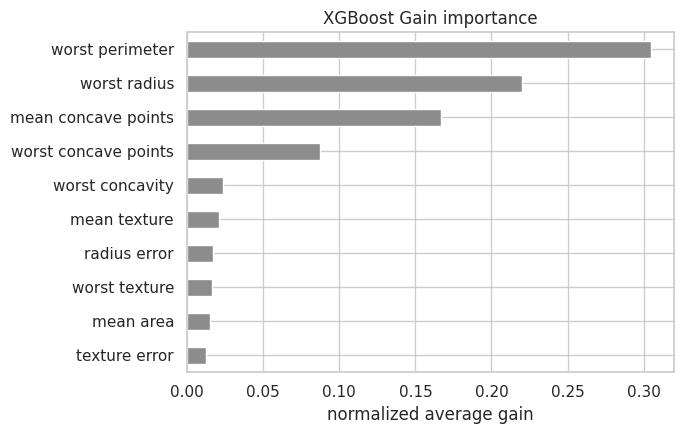

In [ ]:
# ─────────────────────────────────────────────
# [C4] Part 2. Local에서 Global로 · 해석 방법 선택 · 📊 데이터로 확인해 봅시다 — 중요도의 한계를 직접 보기
# ─────────────────────────────────────────────
gain_importance = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values().tail(10)

plt.figure(figsize=(7, 4.5))
gain_importance.plot(kind="barh", color="#8c8c8c")
plt.title("XGBoost Gain importance")
plt.xlabel("normalized average gain")
plt.tight_layout()
plt.show()

print("→ Gain은 이 피처를 사용한 분할이 평균적으로 손실을 얼마나 줄였는지 요약합니다.")
print("→ 방향과 특정 환자의 예측 근거는 알려 주지 않습니다.")

> 🎯 **[C4] 확인하기**  
> 현재 XGBoost의 `feature_importances_`는 기본 설정에서 **Gain 중요도**를 정규화한 값입니다. 모두 0 이상이므로 피처가 악성 확률을 높였는지 낮췄는지는 알 수 없습니다. RandomForest에서 흔히 보는 불순도 기반 중요도(MDI)와 모양은 비슷하지만 계산 기준이 같지 않습니다.

### 질문의 범위를 먼저 정합니다

| 질문                                                   | 필요한 범위 |
| ------------------------------------------------------ | ----------- |
| “테스트 표본에서 모델은 전반적으로 무엇에 의존했는가?” | Global 해석 |
| “이 환자 한 명의 악성 확률은 왜 이렇게 나왔는가?”      | Local 설명  |

Gain과 순열 중요도는 모두 Global 요약입니다. 다음 코드에서 두 방법이 답하는 질문을 비교합니다.

▶️ **코드 실행하기 · 코드 셀 5 [C5]**

In [ ]:
# [C5] Part 2. Local에서 Global로 · 해석 방법 선택 · 📊 데이터로 확인해 봅시다 — 중요도의 한계를 직접 보기
gain_importance = pd.Series(model.feature_importances_, index=X.columns)
permutation_result = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE
)
permutation_importance_mean = pd.Series(
    permutation_result.importances_mean, index=X.columns
)

comparison = pd.DataFrame({
    "XGBoost Gain": gain_importance,
    "Permutation": permutation_importance_mean,
}).sort_values("Permutation", ascending=False).head(6)

print(comparison.round(4).to_string())
print("\nGain = 분할이 평균적으로 줄인 손실")
print("Permutation = 피처를 섞었을 때 줄어든 테스트 정확도")

                      XGBoost Gain  Permutation
worst texture               0.0164       0.0228
worst concavity             0.0233       0.0096
worst concave points        0.0871       0.0088
mean concave points         0.1671       0.0070
worst smoothness            0.0070       0.0044
worst area                  0.0122       0.0018

Gain = 분할이 평균적으로 줄인 손실
Permutation = 피처를 섞었을 때 줄어든 테스트 정확도


### XGBoost Gain·순열 중요도·SHAP 값

세 결과는 모두 “중요도”처럼 보이지만 질문이 다릅니다.

| 해석 결과        | 측정하는 것                           | 답하는 질문                                            | 범위                | 방향           |
| ---------------- | ------------------------------------- | ------------------------------------------------------ | ------------------- | -------------- |
| **XGBoost Gain** | 해당 피처 분할의 평균 손실 감소       | 학습된 트리의 유용한 분할에 어떤 피처가 쓰였는가?      | Global              | 없음           |
| **순열 중요도**  | 피처를 섞었을 때 평가 점수 변화       | 이 피처 정보를 깨뜨리면 테스트 성능이 얼마나 변하는가? | Global              | 예측 방향 아님 |
| **SHAP 값**      | 선택한 모델 출력에 귀속된 피처별 기여 | 이 표본의 출력을 기준값에서 어떻게 나누어 설명하는가?  | Local → Global 집계 | 있음           |

- Gain은 트리 학습 과정의 요약이며 상관된 피처 사이에서 중요도가 쏠릴 수 있습니다.
- 순열 중요도는 대체 가능한 상관 피처가 남아 있으면 작게 나타날 수 있습니다.
- SHAP은 모델 출력의 귀속을 설명하지만, 피처를 제거했을 때의 성능 변화를 직접 측정하지 않습니다.

| 필요한 답                                        | 먼저 볼 방법 |
| ------------------------------------------------ | ------------ |
| 트리의 분할에서 평균적으로 손실을 많이 줄인 피처 | XGBoost Gain |
| 피처 정보를 깨뜨렸을 때 성능 변화                | 순열 중요도  |
| 특정 표본의 예측 근거와 방향                     | Local SHAP   |
| 여러 표본에서 기여의 크기·방향·분포              | Global SHAP  |

> ⚠️ 중요도가 높다는 사실은 좋은 피처이거나 현실의 원인이라는 뜻이 아닙니다. 피처의 생성 시점과 업무 의미를 별도로 확인합니다.

> ⚠️ **가상 점검 사례 — 예상 밖 피처가 상위라면:**  
> 한 모델에서 "고객 ID"가 중요도 1위였습니다. ID는 무작위 번호라 예측과 무관해야 하는데 — 알고 보니 *ID가 가입 순서와 상관*돼 시간 정보가 새어든 거였습니다. 불순도 중요도는 "왜 중요한지"를 안 알려줘 원인 파악이 늦었습니다. SHAP Scatter 플롯에서도 ID 값과 기여의 부자연스러운 패턴을 확인할 수 있습니다. 다만 중요도가 높다는 사실만으로 누수를 확정할 수는 없으며, 피처 생성 시점과 분할 절차를 직접 감사해야 합니다. 해석 도구는 *모델 신뢰성 점검*의 핵심입니다.

> ⚠️ **중요도 ≠ 좋은 피처:**  
> "중요도 1위"가 *반드시 좋은 피처*는 아닙니다. 누수 피처가 1위일 수도, 우연한 상관이 1위일 수도 있습니다. 중요도는 "_모델이 많이 의존한다_"는 사실일 뿐. 그 의존이 업무 정의와 데이터 생성 과정에 비추어 타당한지는 별도로 판단해야 합니다. 이 판단은 어떤 중요도 지표를 쓰더라도 자동으로 나오지 않습니다 — SHAP 결과에서도 마찬가지로 피처의 출처·생성 시점·업무 의미를 함께 확인해야 합니다.

## ⌨️ 백문이 불여일타! (1)

```
[문제]
XGBoost Gain과 순열 중요도가 같은 답을 주는지 확인합니다.

1) 두 중요도의 Top 5 피처가 몇 개 겹치는지 셉니다.
2) 두 순위의 차이가 가장 큰 피처 3개를 찾습니다.
3) 순열 중요도에 음수가 있다면 어떤 뜻인지 설명합니다.

(gain_importance, permutation_importance_mean을 사용합니다.)
```

In [ ]:
# [C6] Part 2 · ⌨️ 백문이 불여일타! (1) — 두 중요도는 같은 답을 주는가

# 여기에 코드를 작성하세요
# ─────────────────────────────────────────────
# Gain 중요도 vs 순열 중요도 비교
# ─────────────────────────────────────────────
from sklearn.inspection import permutation_importance
import pandas as pd

# 1. XGBoost Gain 중요도 (모델 학습 시 이미 사용된 정보 기반, 재계산 불필요)
gain_importance = pd.Series(
    model.feature_importances_,   # importance_type="gain"으로 학습됨
    index=X.columns
)

# 2. 순열 중요도 (테스트셋에서 각 피처를 무작위로 섞었을 때 성능이 얼마나 떨어지는지)
perm_result = permutation_importance(
    model, X_test, y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="accuracy"
)
permutation_importance_mean = pd.Series(
    perm_result.importances_mean,
    index=X.columns
)

# ── 문제 1) Top 5 겹치는 개수 ──────────────────────
gain_top5 = set(gain_importance.nlargest(5).index)
perm_top5 = set(permutation_importance_mean.nlargest(5).index)
overlap = gain_top5 & perm_top5

print("Gain Top 5       :", list(gain_top5))
print("Permutation Top 5:", list(perm_top5))
print(f"겹치는 피처 수    : {len(overlap)}개 →", overlap)

# ── 문제 2) 두 순위 차이가 가장 큰 피처 3개 ──────────
gain_rank = gain_importance.rank(ascending=False)
perm_rank = permutation_importance_mean.rank(ascending=False)

rank_diff = pd.DataFrame({
    "gain_rank": gain_rank,
    "perm_rank": perm_rank,
    "diff": (gain_rank - perm_rank).abs()
}).sort_values("diff", ascending=False)

print("\n순위 차이 Top 3:")
print(rank_diff.head(3))

# ── 문제 3) 순열 중요도 음수 개수 & 의미 ─────────────
n_negative = (permutation_importance_mean < 0).sum()
print(f"\n순열 중요도가 음수인 피처 개수: {n_negative}개")
if n_negative > 0:
    print(permutation_importance_mean[permutation_importance_mean < 0])


# 왜 이렇게 짰나 — Gain 중요도는 model.feature_importances_에 이미 있으니 재학습 없이 바로 씀. 순열 중요도는 "이 피처를 랜덤하게 섞으면 성능이 얼마나 나빠지는가"를 직접 관찰하는 방식이라 테스트셋(X_test)에서 계산해야 함(훈련셋으로 하면 과적합된 성능 하락폭을 재는 셈이라 왜곡됨). n_repeats=30은 섞는 무작위성 때문에 여러 번 반복해 평균낸 것.
# 어디서 틀릴 수 있나 —
# Gain 중요도는 훈련 과정에서 그 피처가 분기 기준으로 얼마나 유용했는지를 재는 것 (모델 내부 관점), 순열 중요도는 실제 테스트 성능에 얼마나 필요한지를 재는 것 (모델 외부 관점) — 서로 다른 걸 재고 있어서 순위가 다를 수 있는 게 당연함.
# permutation_importance를 X_train에 돌리면 과적합 때문에 왜곡된 결과 나옴 — 반드시 X_test로.
# 상관관계 높은 피처들(유방암 데이터엔 mean radius/worst radius처럼 비슷한 피처가 많음)이 있으면, 순열 중요도가 과소평가될 수 있음 — 하나를 섞어도 상관된 다른 피처가 정보를 대신 제공해서 성능이 별로 안 떨어지기 때문.
# 결과를 어떻게 신뢰하나 —
# 겹치는 피처 수가 5개 중 3~4개 정도면 "대체로 일치하되 관점 차이로 순서는 다름" 정도로 해석 가능.
# 음수 값의 의미: 순열 중요도가 음수라는 건 "이 피처를 무작위로 섞었더니 오히려 성능이 (미세하게) 좋아졌다"는 뜻 — 실제로 그 피처가 유용해서가 아니라, **n_repeats 반복 중 우연한 변동(noise)**일 가능성이 높음. 즉 "이 피처는 사실상 기여도가 0에 가깝다"로 해석해야지, "이 피처가 예측을 방해한다"고 해석하면 안 됨 (이게 오늘 규칙의 "SHAP/중요도를 현실 원인처럼 서술하지 않기"와 같은 맥락).

Gain Top 5       : ['worst concavity', 'worst perimeter', 'worst radius', 'worst concave points', 'mean concave points']
Permutation Top 5: ['worst concavity', 'worst area', 'worst texture', 'worst concave points', 'mean concave points']
겹치는 피처 수    : 3개 → {'worst concavity', 'mean concave points', 'worst concave points'}

순위 차이 Top 3:
                 gain_rank  perm_rank  diff
worst perimeter        1.0       30.0  29.0
worst radius           2.0       25.0  23.0
radius error           7.0       26.0  19.0

순열 중요도가 음수인 피처 개수: 11개
mean texture        -0.001754
mean area           -0.002632
mean smoothness     -0.001754
mean compactness    -0.001170
radius error        -0.002047
area error          -0.000292
compactness error   -0.004094
symmetry error      -0.003801
worst radius        -0.002047
worst perimeter     -0.004386
worst symmetry      -0.001170
dtype: float64


<details>
<summary>(클릭) 💡 힌트</summary>

- 상위 이름은 `gain_importance.nlargest(5).index`처럼 얻습니다.
- 순위는 `.rank(ascending=False)`로 매깁니다.
- 음수 개수는 `(permutation_importance_mean < 0).sum()`으로 셉니다.

</details>

## 🚦 짚고 넘어가기

1. Local 설명과 Global 해석은 각각 무엇을 설명하나요?
2. Local 설명을 모아 Global 해석을 만들 수 있지만 반대는 안 되는 이유는 무엇인가요?
3. XGBoost Gain이 알려 주지 않는 두 가지는 무엇인가요?
4. 피처를 제거해도 성능이 유지되는지 판단하려면 무엇을 추가로 해야 하나요?

> ⏭️ **다음 학습 예고**  
> “이 환자 한 명을 왜 이렇게 예측했는가?”라는 질문에는 앞서 비교한 세 방법 중 SHAP 값이 필요한 정보를 제공합니다. 다음 Part에서는 기준값과 한계 기여도를 이용해 SHAP 값이 정해지는 원리를 손으로 확인합니다.

# Part 3. SHAP 값의 원리 — 손으로 계산해 보기

**SHAP(SHapley Additive exPlanations)** 은 예측 한 건을 기준값과 피처별 **SHAP 값(SHAP Value)** 으로 나눕니다.

> ❓ **질문하기**  
> SHAP 값은 어떤 규칙으로 정하며, 피처별 기여를 더하면 왜 원래 예측이 되는가?

## 💡 코드 전에 구분할 다섯 용어

| 용어                        | 초보자용 뜻                           | 이 노트북의 예               |
| --------------------------- | ------------------------------------- | ---------------------------- |
| **피처값(Feature value)**   | 모델에 들어간 실제 입력               | `mean radius=17.99`          |
| **모델 출력(Model output)** | 지금 설명하려는 예측 결과             | 악성 확률 `0.82`             |
| **기준값(Base value)**      | 배경 집단에서 출발하는 평균 모델 출력 | 예: `0.35`                   |
| **SHAP 값(SHAP value)**     | 한 피처에 귀속된 출력 변화량          | 예: `+0.08`                  |
| **예측 식**                 | 기준값과 모든 기여의 합               | `기준값 + ΣSHAP = 예측 확률` |

SHAP 숫자를 읽기 전에는 세 가지를 확인합니다.

| 질문                    | 이 노트북의 답                        |
| ----------------------- | ------------------------------------- |
| 누구의 예측인가?        | 테스트 표본 한 건 또는 테스트셋 114건 |
| 어떤 출력을 설명하는가? | 클래스 1(`malignant`)의 확률          |
| 무엇과 비교하는가?      | 학습셋에서 뽑은 배경 데이터 100건     |

`SHAP=+0.08`은 “피처값이 0.08이다”가 아니라, **이 표본에서 해당 피처가 악성 확률을 기준값보다 8%p 높이는 방향으로 기여했다**는 뜻입니다.

## 손으로 SHAP 값을 구해 봅시다 — 3개 피처의 조합 가중치

피처 3개의 **모든 조합**을 사용해 SHAP 값을 계산합니다. 구독형 스트리밍 서비스 모두플레이가 고객 한 명의 이탈 점수를 예측한다고 가정합니다.

| 기호 | 피처                    | 이 고객의 값 |
| ---- | ----------------------- | ------------ |
| A    | `days_since_last_watch` | 21일         |
| B    | `support_tickets`       | 3건          |
| C    | `payment_failures`      | 1건          |

> ⚠️ 이탈 점수는 계산 원리를 위한 가상의 출력입니다. 실제 XGBoost 예제에서는 악성 **확률**을 분해하지만, `기준값 + 피처별 SHAP 값 = 모델 출력`이라는 구조는 같습니다.

### 1단계 — 피처 조합 8개의 모델 출력을 준비합니다

피처가 3개이므로 가능한 조합은 `2³=8`개입니다. `v(S)`는 집합 `S`의 피처 정보를 알고 있을 때의 모델 출력입니다.

| 조합 `S`  | 알고 있는 피처        | `v(S)` 이탈 점수 |
| --------- | --------------------- | ---------------: |
| `∅`       | 없음                  |               28 |
| `{A}`     | 미시청일수            |               32 |
| `{B}`     | 문의 횟수             |               31 |
| `{C}`     | 결제 실패             |               30 |
| `{A,B}`   | 미시청일수, 문의 횟수 |               32 |
| `{A,C}`   | 미시청일수, 결제 실패 |               33 |
| `{B,C}`   | 문의 횟수, 결제 실패  |               32 |
| `{A,B,C}` | 세 피처 모두          |               35 |

설명이 나누어야 할 총 변화량은 다음과 같습니다.

```text
최종 출력 − 기준값 = 35 − 28 = 7
```

### 2단계 — A가 합류할 때의 한계 기여를 구합니다

A의 한계 기여는 **A가 없는 조합의 출력**과 **그 조합에 A를 추가한 출력**의 차이입니다.

| A보다 먼저 있는 피처 집합 `S` |     A 추가 전 |       A 추가 후 | A의 한계 기여 |
| ----------------------------- | ------------: | --------------: | ------------: |
| `∅`                           |     `v(∅)=28` |     `v({A})=32` |     `32−28=4` |
| `{B}`                         |   `v({B})=31` |   `v({A,B})=32` |     `32−31=1` |
| `{C}`                         |   `v({C})=30` |   `v({A,C})=33` |     `33−30=3` |
| `{B,C}`                       | `v({B,C})=32` | `v({A,B,C})=35` |     `35−32=3` |

한계 기여 네 개를 단순 평균하면 안 됩니다. **조합의 크기에 따라** 가능한 합류 순서에서 나타나는 횟수가 다르기 때문에 **Shapley 조합 가중치**를 적용합니다.

### 3단계 — 조합 가중치를 계산합니다

전체 피처 수를 `M`, A보다 먼저 있는 피처 집합을 `S`라고 하면 가중치는 다음과 같습니다.

$$
w(S)=\frac{|S|!(M-|S|-1)!}{M!}
$$

여기서는 `M=3`입니다.

| `S`의 크기 | 계산           | 조합 하나의 가중치 |
| ---------: | -------------- | -----------------: |
|        0개 | `0! × 2! / 3!` |              `1/3` |
|        1개 | `1! × 1! / 3!` |              `1/6` |
|        2개 | `2! × 0! / 3!` |              `1/3` |

따라서 A의 네 가지 한계 기여에는 차례로 `1/3`, `1/6`, `1/6`, `1/3`이 붙습니다.

```text
1/3 + 1/6 + 1/6 + 1/3 = 1
```

> 💡 **왜 이 가중치인가요?**  
> 피처 3개의 합류 순서는 `3!=6`개입니다. A가 첫 번째인 순서는 2개이므로 `2/6=1/3`, 특정 피처 하나 다음에 A가 오는 순서는 1개이므로 `1/6`, A가 마지막인 순서는 2개이므로 `2/6=1/3`입니다. 즉 **조합 가중치 계산과 모든 합류 순서의 평균은 같은 계산**입니다.

### 4단계 — A의 SHAP 값을 계산합니다

$$
\begin{aligned}
\phi_A
&=4\times\frac{1}{3}
+1\times\frac{1}{6}
+3\times\frac{1}{6}
+3\times\frac{1}{3} \\
&=3
\end{aligned}
$$

따라서 이 고객에서 A의 SHAP 값은 `3`입니다.

### 5단계 — B와 C도 같은 방식으로 계산합니다

| 설명 피처 | 가중할 한계 기여                | SHAP 값 |
| --------- | ------------------------------- | ------: |
| A         | `4×1/3 + 1×1/6 + 3×1/6 + 3×1/3` |       3 |
| B         | `3×1/3 + 0×1/6 + 2×1/6 + 2×1/3` |       2 |
| C         | `2×1/3 + 1×1/6 + 1×1/6 + 3×1/3` |       2 |

### 6단계 — 합산성을 검산합니다

```text
기준값 28 + SHAP(A) 3 + SHAP(B) 2 + SHAP(C) 2
         = 35 = 세 피처를 모두 사용한 모델 출력 ✓
```

SHAP 값의 합 `3+2+2=7`은 최종 출력과 기준값의 차이 `35−28=7`과 같습니다.

> 💡 **핵심짚기**  
> SHAP 값은 각 조합에서 측정한 한계 기여에 **그 조합이 가능한 모든 합류 순서에서 나타나는 비율**을 가중해 더한 값입니다. 가중치는 모델 학습 가중치나 XGBoost leaf score가 아니라, 피처 조합을 공평하게 반영하기 위한 **Shapley 조합 가중치**입니다.

## 피처가 많아지면 Explainer가 필요합니다

피처 3개에서는 8개 조합과 6개 합류 순서를 손으로 확인할 수 있지만, 피처가 늘면 계산량이 급격히 증가합니다.

| 피처 수 |   가능한 조합 | 가능한 합류 순서 |
| ------: | ------------: | ---------------: |
|       2 |             4 |                2 |
|       3 |             8 |                6 |
|       5 |            32 |              120 |
|      10 |         1,024 |        3,628,800 |
|  **30** | **약 10.7억** | **약 2.65×10³²** |

SHAP 라이브러리는 모델 구조와 설명 방식에 맞는 여러 Explainer를 제공합니다.

| 모델·상황        | Explainer 예                             | 특징                                                      |
| ---------------- | ---------------------------------------- | --------------------------------------------------------- |
| 트리·트리 앙상블 | `TreeExplainer`                          | 트리 구조를 이용해 SHAP 값을 효율적으로 계산              |
| 선형 모델        | `LinearExplainer`                        | 선형 모델 구조를 이용하며 피처 의존성 설정 확인 필요      |
| 일부 딥러닝 모델 | `DeepExplainer`·`GradientExplainer`      | 신경망 구조를 활용한 근사 방법                            |
| 일반 예측 함수   | `KernelExplainer`·`PermutationExplainer` | 모델 종류에 덜 의존하지만 계산 비용과 근사 오차 확인 필요 |

> 📌 **이번 실습에서는** XGBoost를 설명하므로 `TreeExplainer`를 사용합니다. 손계산의 조합을 30개 피처에서 직접 열거하지 않고, 트리 구조를 활용해 같은 Shapley 귀속 원리를 계산합니다.

## “피처가 없다”는 0을 넣는다는 뜻이 아니다

손계산 1단계에서 넘어간 것이 하나 있습니다 — 표의 첫 줄, **"알고 있는 피처: 없음"의 출력 `10`은 어떻게 계산했을까요.** 모델은 입력을 비워 둔 채로 예측할 수 없습니다. 무언가는 넣어야 합니다.

그 무언가가 `0`은 아닙니다. SHAP 계산에서 피처를 모른다고 가정하는 일은 관측값을 무조건 `0`으로 바꾸는 것과 다릅니다.

| 상황                 | 의미                                                  |
| -------------------- | ----------------------------------------------------- |
| 피처값이 `0`         | 실제 관측값이 0                                       |
| 피처를 가림(Masking) | 해당 피처 정보를 사용하지 않는 상황을 구성            |
| 배경 데이터          | 가려진 정보를 어떤 비교 집단으로 대신할지 정하는 기준 |

따라서 SHAP 설명에는 항상 **“무엇과 비교했는가?”** 가 따라옵니다. 같은 표본과 같은 모델도 배경 집단과 피처 의존성 처리 방식이 달라지면 기준값과 기여 배분이 달라질 수 있습니다.

## 배경 데이터 — 무엇과 비교하는가

SHAP은 피처가 가려진 상황을 만들 때 **배경 데이터(Background data)** 를 비교 기준으로 사용합니다. 이 노트북은 학습셋에서 대표 표본 100건을 뽑습니다.

```python
background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
```

배경 집단을 바꾸면 기준값과 SHAP 값도 달라질 수 있습니다. 그래서 설명 리포트에는 배경 데이터의 출처와 크기를 기록해야 합니다.

<details>
<summary>(클릭) 📖 심화 — 로그오즈와 피처 의존성 처리</summary>

트리 모델의 기본 `raw` 출력은 이진 분류에서 보통 로그오즈입니다. 로그오즈 SHAP을 확률 변화량으로 바로 읽으면 안 됩니다. 이 노트북은 초보자 해석을 위해 명시적 배경 데이터와 `feature_perturbation="interventional"`, `model_output="probability"`를 사용합니다. 다른 설정에서는 출력 단위와 피처 의존성 가정을 다시 확인해야 합니다.

</details>

## 📊 실제 모델로 확인하기 — `Explanation` 객체 만들기

실제 30개 피처에서는 `TreeExplainer`가 SHAP 값을 계산합니다. 결과는 값·기준값·피처값·피처명을 한데 묶은 **`Explanation` 객체**입니다.

> 🤔 **예상하기**  
> 테스트 표본이 114건이고 피처가 30개라면 SHAP 값 배열의 모양은 무엇일까요?

▶️ **코드 실행하기 · 코드 셀 7 [C7]**

In [ ]:


explainer = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent",
    model_output="raw",
)
shap_explanation = explainer(X_test)
shap_values = shap_explanation.values

print("객체 유형:", type(shap_explanation).__name__)
print("SHAP 값 모양:", shap_values.shape, "= 표본 × 피처")
print("기준값 모양:", np.asarray(shap_explanation.base_values).shape)
print("피처명 예시:", list(shap_explanation.feature_names[:3]))

객체 유형: Explanation
SHAP 값 모양: (114, 30) = 표본 × 피처
기준값 모양: (114,)
피처명 예시: ['mean radius', 'mean texture', 'mean perimeter']


> 🎯 **[C7] 확인하기**

| `Explanation` 구성 | 의미                    |
| ------------------ | ----------------------- |
| `.values`          | 각 표본·피처의 SHAP 값  |
| `.base_values`     | 각 표본 설명의 기준값   |
| `.data`            | 실제 피처값             |
| `.feature_names`   | SHAP 열과 연결된 피처명 |

`shap_values[i, j]`는 **표본 `i`에서 피처 `j`에 귀속된 악성 확률 기여**입니다. 이제 한 표본에서 합산성을 검산합니다.

▶️ **코드 실행하기 · 코드 셀 8 [C8]**

In [ ]:

sample_index = 0
base_margin = float(shap_explanation.base_values[sample_index])
shap_sum = float(shap_values[sample_index].sum())
reconstructed_margin = base_margin + shap_sum
predicted_margin = float(model.predict(X_test.iloc[[sample_index]], output_margin=True)[0])  # ← 여기가 핵심 차이

print(f"기준 악성 margin      = {base_margin:.6f}")
print(f"SHAP 값의 합           = {shap_sum:+.6f}")
print(f"기준값 + SHAP 합       = {reconstructed_margin:.6f}")
print(f"모델의 실제 margin     = {predicted_margin:.6f}")
print("합산성 확인            =", np.isclose(
    reconstructed_margin, predicted_margin, atol=1e-6
))

기준 악성 margin      = -0.537726
SHAP 값의 합           = -5.831847
기준값 + SHAP 합       = -6.369573
모델의 실제 margin     = -6.369572
합산성 확인            = True


> 🎯 **[C8] 확인하기**  
> `기준값 + 모든 SHAP 값의 합`이 모델의 악성 확률과 허용 오차 안에서 같습니다. 이것이 **합산성**입니다. 여기서는 출력 공간을 확률로 지정했으므로 `+0.05`를 악성 확률을 **5%p 높이는 기여**로 읽을 수 있습니다.

> ⚠️ 개별 기여는 다른 피처와 독립적으로 그 피처만 바꿨을 때 생기는 인과 효과가 아닙니다. 현재 모델·배경 데이터·설명 설정에서 귀속된 몫입니다.

▶️ **코드 실행하기 · 코드 셀 9 [C9]**

In [ ]:
# [C9] Part 3. SHAP 값의 원리 — 손으로 계산해 보기 · 📊 실제 모델로 확인하기 — Explanation 객체 만들기
sample_index = 0
contribution_table = pd.DataFrame({
    "feature_value": X_test.iloc[sample_index],
    "SHAP_value_margin": shap_values[sample_index],  # margin(log-odds) 단위
})
contribution_table["direction"] = np.select(
    [
        contribution_table["SHAP_value_margin"] > 0,
        contribution_table["SHAP_value_margin"] < 0,
    ],
    ["malignant 방향 ↑", "malignant 방향 ↓"],
    default="기여 없음"
)
order = contribution_table["SHAP_value_margin"].abs().sort_values(ascending=False).index
print(contribution_table.loc[order].head(5).round(4).to_string())

# (선택) 참고용 최종 확률 — 전체 합에만 sigmoid 적용, 개별 피처엔 적용 안 함
from scipy.special import expit
final_margin = shap_values[sample_index].sum() + shap_explanation.base_values[sample_index]
print(f"\n이 표본의 최종 악성 확률: {expit(final_margin):.4f}")

                     feature_value  SHAP_value_margin       direction
worst texture              15.9700            -1.5619  malignant 방향 ↓
worst area                510.5000            -0.8144  malignant 방향 ↓
area error                 10.5000            -0.7967  malignant 방향 ↓
mean concave points         0.0262            -0.7853  malignant 방향 ↓
worst radius               12.8200            -0.7408  malignant 방향 ↓

이 표본의 최종 악성 확률: 0.0017


> 🎯 **[C9] 확인하기**

| 구분      | 질문                              | 주의할 오해                  |
| --------- | --------------------------------- | ---------------------------- |
| 피처값    | 실제 입력값은 얼마인가?           | 큰 피처값 = 양수 SHAP이 아님 |
| SHAP 부호 | 악성 확률을 높였나, 낮췄나?       | 양수 SHAP = 좋은 결과가 아님 |
| SHAP 크기 | 이 표본에서 얼마나 크게 귀속됐나? | 현실의 원인 크기가 아님      |

피처값과 SHAP 값은 서로 다른 숫자입니다. 양수 SHAP은 오직 **설명 대상인 악성 확률을 높이는 방향**을 뜻합니다.

## Local에서 Global로 — 왜 평균 절댓값을 쓰는가

한 피처도 표본마다 양수·음수 SHAP을 가질 수 있습니다. 부호를 그대로 평균하면 서로 상쇄되므로, 전역 기여 크기는 보통 `mean(|SHAP|)`으로 요약합니다.

```text
표본별 SHAP → 절댓값 → 표본 전체 평균 → 전역 평균 |SHAP|
```

절댓값 평균은 **크기만 남기고 방향을 버립니다.** 그래서 Bar 플롯은 전역 크기, Beeswarm은 표본별 부호·분포·피처값을 함께 확인할 때 사용합니다.

▶️ **코드 실행하기 · 코드 셀 10 [C10]**

피처: mean concave points
malignant 방향 log-odds 증가 기여 표본: 45건
malignant 방향 log-odds 감소 기여 표본: 69건
Global mean(|SHAP|): 0.9724


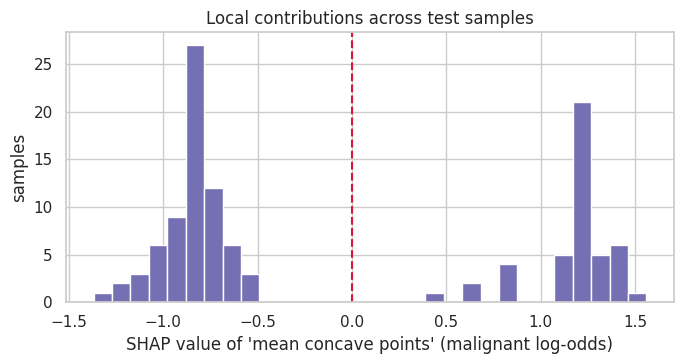

In [ ]:


# [C10] Part 3. SHAP 값의 원리 — 손으로 계산해 보기 · Local에서 Global로 — 왜 평균 절댓값을 쓰는가
global_shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X.columns
)
top_feature = global_shap_importance.idxmax()
feature_index = list(X.columns).index(top_feature)
feature_shap_values = shap_values[:, feature_index]
plt.figure(figsize=(7, 3.8))
plt.hist(feature_shap_values, bins=30, color="#7570b3", edgecolor="white")
plt.axvline(0, color="crimson", linestyle="--")
plt.xlabel(f"SHAP value of '{top_feature}' (malignant log-odds)")  # 수정
plt.ylabel("samples")
plt.title("Local contributions across test samples")
plt.tight_layout()
plt.show()
print(f"피처: {top_feature}")
print(f"malignant 방향 log-odds 증가 기여 표본: {(feature_shap_values > 0).sum()}건")  # 수정
print(f"malignant 방향 log-odds 감소 기여 표본: {(feature_shap_values < 0).sum()}건")  # 수정
print(f"Global mean(|SHAP|): {np.abs(feature_shap_values).mean():.4f}")  # log-odds 단위 평균

## 🚦 짚고 넘어가기

1. 피처값·기준값·SHAP 값은 어떻게 다른가요?
2. 피처 3개일 때 `S`의 크기가 0·1·2개인 조합 하나의 가중치는 각각 얼마인가요?
3. 조합 가중치 계산과 모든 합류 순서의 평균이 같은 이유는 무엇인가요?
4. `기준값 + ΣSHAP`은 무엇과 같아야 하나요?
5. 이 노트북에서 양수 SHAP은 무엇을 뜻하나요?
6. 배경 데이터는 어떤 역할을 하나요?
7. `mean(|SHAP|)`으로 Global 크기를 만들 때 잃는 정보는 무엇인가요?

> ⏭️ **다음 학습 예고**  
> 숫자만으론 와닿지 않습니다. SHAP의 진가는 **시각화**에 있습니다 — 전역 요약과 개별 설명을 그림으로 봅니다.

# Part 4. SHAP 시각화 — 질문에 맞는 그림 읽기

SHAP 그림은 많지만 처음에는 네 가지 질문만 구분하면 됩니다.

> ❓ **질문하기**  
> 전체 경향과 한 표본의 근거를 어떤 그림으로 확인하는가?

## 💡 쉽게 말하면 — 같은 곳을 담은, 축척이 다른 지도들

같은 도시를 설명할 때도 목적에 따라 다른 지도를 꺼냅니다. 전국 지도로는 "어느 도시가 큰가"를 보고, 동네 약도로는 "이 건물을 어떻게 찾아가나"를 봅니다. 둘 중 하나가 더 정확한 것이 아니라 **답하는 질문이 다릅니다.**

SHAP 시각화도 그렇습니다. 그림이 여러 장인 이유는 SHAP이 복잡해서가 아니라, **하나의 SHAP 값을 서로 다른 축척으로 들여다보기 때문**입니다. 전체 경향을 보여주는 그림과 한 사람을 설명하는 그림은 같은 숫자에서 나옵니다.

그래서 "어떤 그림이 제일 좋은가"는 잘못된 질문입니다. **지금 내가 무엇을 묻고 있는가**가 그림을 고릅니다.

## 🔍 시각화 4종 — 무엇을 묻는가

| 그림      | 범위   | 답하는 질문                                    | 먼저 볼 것                  |
| --------- | ------ | ---------------------------------------------- | --------------------------- | ---- | --- |
| Beeswarm  | Global | 여러 표본에서 중요도·방향·분포는 어떠한가?     | 세로 순위, 가로 부호, 점 색 |
| Bar       | Global | 평균적인 기여 크기가 큰 피처는 무엇인가?       | 평균 `                      | SHAP | `   |
| Waterfall | Local  | 이 표본의 확률이 기준값에서 어떻게 이동했는가? | 기준값, 최종값, 기여 방향   |
| Scatter   | Global | 한 피처값과 그 피처의 기여는 어떤 관계인가?    | x=피처값, y=SHAP 값         |

> ⚠️ Bar는 방향을 버립니다. Waterfall 한 장은 한 표본만 설명합니다. 그림 하나로 모든 질문에 답하려 하지 않습니다.

## 📊 데이터로 확인해 봅시다 — 네 장을 차례로 그려 보기

> 🤔 **예상하기**  
> summary plot은 점 하나가 표본 하나입니다. 그 점들이 **좌우로 길게 퍼진 피처**와 **가운데 뭉친 피처**는 무엇이 다를까요?

▶️ **코드 실행하기 · 코드 셀 11 [C11]**

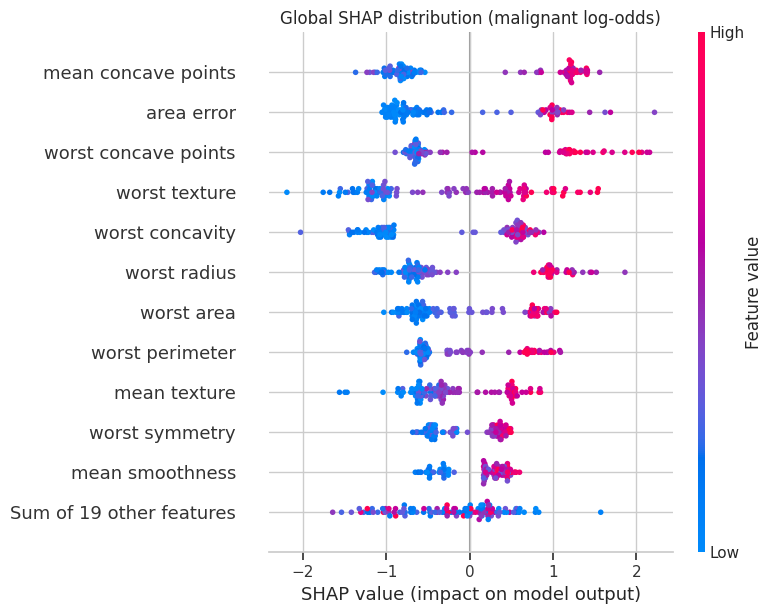

In [ ]:


# [C11] Part 4. SHAP 시각화 — 질문에 맞는 그림 읽기 · 📊 데이터로 확인해 봅시다 — 네 장을 차례로 그려 보기
shap.plots.beeswarm(shap_explanation, max_display=12, show=False)
plt.title("Global SHAP distribution (malignant log-odds)")  # 수정
plt.tight_layout()
plt.show()

> 🎯 **[C11] 확인하기**  
> 점 하나는 표본 하나입니다. 오른쪽은 악성 확률 증가 기여, 왼쪽은 감소 기여입니다. 색은 실제 피처값의 크기입니다. **붉은 점이 오른쪽에 많다**면 높은 피처값이 악성 확률 증가 기여와 함께 나타났다는 뜻이지 인과 효과를 증명한 것은 아닙니다.

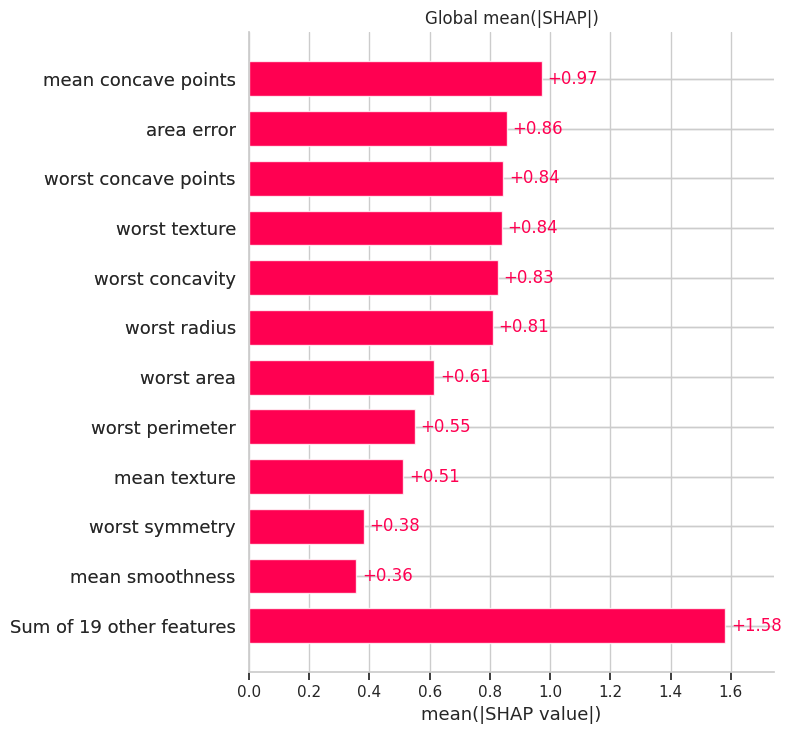

In [ ]:
# [C12] Part 4. SHAP 시각화 — 질문에 맞는 그림 읽기 · 📊 데이터로 확인해 봅시다 — 네 장을 차례로 그려 보기
shap.plots.bar(shap_explanation, max_display=12, show=False)
plt.title("Global mean(|SHAP|)")
plt.tight_layout()
plt.show()

### Waterfall — 이 표본은 왜 이렇게 예측됐나

Waterfall은 기준 확률에서 출발해 각 피처가 악성 확률을 어느 방향으로 얼마나 밀었는지 보여 줍니다.

▶️ **코드 실행하기 · 코드 셀 13 [C13]**

표본 0의 악성 예측 확률: 0.002
(아래 waterfall plot의 숫자는 확률이 아니라 log-odds(margin) 단위입니다)


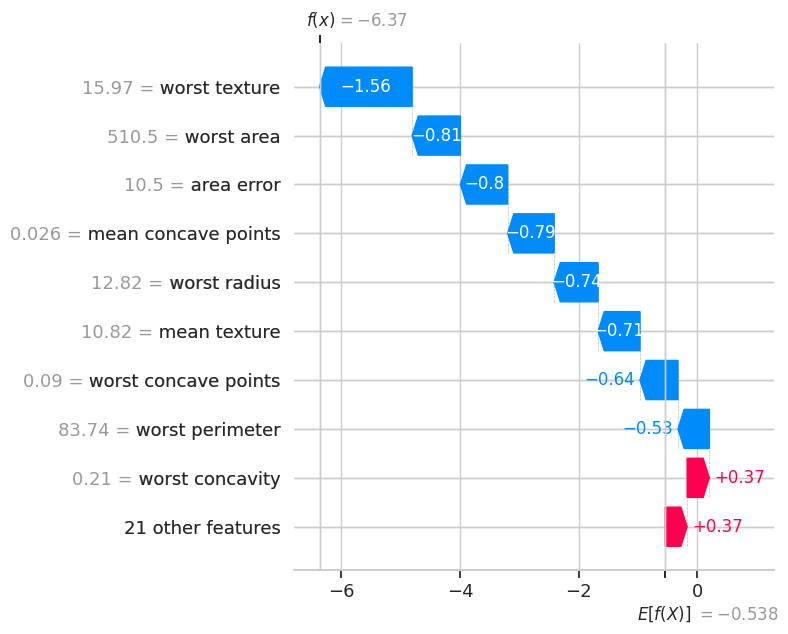

In [ ]:


sample_index = 0
print(f"표본 {sample_index}의 악성 예측 확률: "
      f"{model.predict_proba(X_test.iloc[[sample_index]])[0, 1]:.3f}")
print("(아래 waterfall plot의 숫자는 확률이 아니라 log-odds(margin) 단위입니다)")

shap.plots.waterfall(shap_explanation[sample_index], max_display=10, show=False)
plt.tight_layout()
plt.show()

> 👀 **[C13] 결과읽기**  
> 아래에서 위로 읽습니다. `E[f(X)]`는 배경 데이터에서의 기준 악성 확률, `f(x)`는 이 표본의 최종 악성 확률입니다. 붉은 기여는 악성 확률을 높이고 파란 기여는 낮춥니다. 작은 나머지 피처는 한 줄로 묶입니다.

### 같은 모델도 표본이 바뀌면 설명이 달라집니다

악성 확률이 가장 높은 표본과 가장 낮은 표본을 나란히 설명합니다. 두 Waterfall의 피처와 방향이 왜 다른지 비교해 보세요.

▶️ **코드 실행하기 · 코드 셀 14 [C14]**

In [ ]:
for label, index in [("highest", high_index), ("lowest", low_index)]:
    print(f"\n=== {label}: sample {index}, p={malignant_probabilities[index]:.3f} ===")
    table = pd.DataFrame({
        "feature_value": X_test.iloc[index],
        "SHAP_value_margin": shap_values[index],
    }).sort_values("SHAP_value_margin", key=abs, ascending=False)
    print(table.head(8).round(3).to_string())


=== highest: sample 12, p=1.000 ===
                      feature_value  SHAP_value_margin
worst concave points          0.187              1.155
mean concave points           0.097              1.148
area error                   69.650              0.894
worst radius                 23.720              0.887
worst area                 1724.000              0.744
worst texture                35.900              0.740
worst perimeter             159.800              0.654
worst concavity               0.575              0.646

=== lowest: sample 100, p=0.000 ===
                      feature_value  SHAP_value_margin
worst concavity               0.010             -1.033
area error                   16.800             -0.983
worst texture                22.880             -0.880
mean concave points           0.011             -0.821
worst radius                 10.650             -0.759
worst concave points          0.022             -0.660
worst area                  347.300           

### Scatter — 피처값과 기여의 관계

가장 큰 Global 평균 `|SHAP|`을 가진 피처 하나를 골라, 실제 피처값과 악성 확률 기여의 관계를 봅니다.

▶️ **코드 실행하기 · 코드 셀 15 [C15]**

선택한 피처: mean concave points


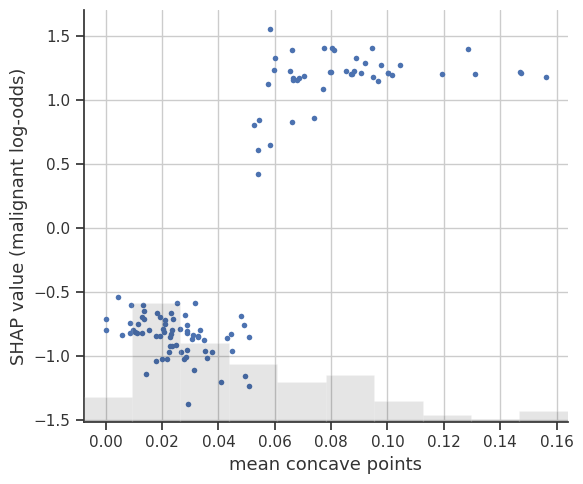

In [ ]:
# [C15] Part 4. SHAP 시각화 — 질문에 맞는 그림 읽기 · 📊 데이터로 확인해 봅시다 — 네 장을 차례로 그려 보기
top_feature = np.abs(shap_explanation.values).mean(axis=0).argmax()
top_feature_name = shap_explanation.feature_names[top_feature]
print("선택한 피처:", top_feature_name)
shap.plots.scatter(
    shap_explanation[:, top_feature_name], color=None, show=False
)
plt.ylabel("SHAP value (malignant log-odds)")  # 수정
plt.tight_layout()
plt.show()

## ⌨️ 백문이 불여일타! (2)

```
[문제]
summary plot에서 눈으로 본 '좌우 퍼짐'을 숫자로 확인합니다.

1) 평균 |SHAP|이 큰 상위 3개 피처를 구합니다.
2) 각 피처마다 SHAP 값이 양수인 표본 수와 음수인 표본 수를 셉니다.
3) 셋 중 가장 '양쪽으로 갈리는' 피처는 무엇인지, 그것이 무엇을 뜻하는지 설명합니다.

(shap_values 는 SHAP 값 배열, X_test 는 테스트 세트입니다)
```

In [ ]:
# [C16] Part 4 · ⌨️ 백문이 불여일타! (2) — 좌우 퍼짐을 숫자로 확인하기

# 여기에 코드를 작성하세요

# ─────────────────────────────────────────────
# summary plot의 좌우 퍼짐을 숫자로 확인
# ─────────────────────────────────────────────

# 1) 평균 |SHAP| 상위 3개 피처
mean_abs_shap = np.abs(shap_values).mean(axis=0)  # 피처별 평균 → axis=0
top3_features = pd.Series(mean_abs_shap, index=X_test.columns).nlargest(3).index

# 2) 각 피처마다 양수/음수 표본 수 세기
rows = []
for feature in top3_features:
    col_index = X_test.columns.get_loc(feature)
    col = shap_values[:, col_index]
    rows.append({
        "feature": feature,
        "mean_abs_shap": mean_abs_shap[col_index],
        "positive_count": (col > 0).sum(),
        "negative_count": (col < 0).sum(),
    })

result_table = pd.DataFrame(rows)
print(result_table.to_string(index=False))

# 3) 가장 '양쪽으로 갈리는' 피처 찾기
# 갈림의 정도 = 양수/음수 개수가 얼마나 50:50에 가까운지로 측정
result_table["split_balance"] = 1 - abs(
    result_table["positive_count"] - result_table["negative_count"]
) / (result_table["positive_count"] + result_table["negative_count"])

most_split_feature = result_table.loc[result_table["split_balance"].idxmax(), "feature"]
print(f"\n가장 양쪽으로 갈리는 피처: {most_split_feature}")

# **"양쪽으로 갈린다"**는 건 이 피처가 표본에 따라 정반대 역할을 한다는 뜻이야:

# 어떤 표본에서는 malignant 쪽으로 세게 밀고 (45건)
# 어떤 표본에서는 benign 쪽으로 세게 민다 (69건)

# 이건 방금 [C15] 산점도에서 직접 봤던 그 "두 뭉치(0.05 경계 기준으로 갈리는 계단식 패턴)"가 숫자로도 확인된 거야. 즉 이 피처는 **"항상 malignant를 가리키는 신호"가 아니라, "값의 크기에 따라 정반대 신호를 주는 피처"**라는 뜻.

# 반면 area error와 worst concave points는 비교적 음수(benign 방향)에 더 쏠려있다는 건, 이 두 피처는 "대부분의 표본에서 benign 쪽으로 작용하는 경향이 좀 더 강하다"는 뜻이야 — 물론 여전히 방향이 갈리는 표본도 30%대로 꽤 있으니 절대적인 건 아님.

# 주의할 점 (오늘 규칙)

# 이 "양쪽으로 갈림"이 "이 피처가 애매하고 신뢰할 수 없다"는 뜻은 아니야. 오히려 [C15]에서 봤듯, 값이 작을 때는 확실히 benign, 값이 클 때는 확실히 malignant로 매우 일관되게 갈리는 거였어 — "갈린다"는 건 "피처값 크기에 따라 방향이 정해진다"는 뜻이지 "무작위로 왔다갔다 한다"는 뜻이 아니야. 이 구분을 헷갈리면 안 돼.

             feature  mean_abs_shap  positive_count  negative_count
 mean concave points       0.972363              45              69
          area error       0.856324              36              78
worst concave points       0.844117              37              77

가장 양쪽으로 갈리는 피처: mean concave points


<details>
<summary>(클릭) 💡 힌트</summary>

- 평균 `|SHAP|`은 `np.abs(shap_values).mean(axis=0)`입니다 — 피처별로 평균을 내야 하니 `axis=0`입니다.
- 피처 이름으로 열 번호를 찾을 때는 `X_test.columns.get_loc(피처명)`을 씁니다.
- 양수 개수는 `(col > 0).sum()`, 음수 개수는 `(col < 0).sum()`으로 셉니다.
- 결과를 `dict` 목록에 모아 `pd.DataFrame(rows)`로 만들면 표로 한 번에 볼 수 있습니다.

</details>

## 🚦 짚고 넘어가기

1. summary plot에서 *색*과 *가로 위치*는 각각 무엇을 뜻하나요?
2. 전역 요약과 개별 설명은 SHAP에서 어떻게 연결되나요?
3. 개별 SHAP 설명은 실무 어디에 쓰이나요?

> ⏭️ **다음 학습 예고**  
> SHAP을 *디버깅·방향 해석*에 어떻게 쓰는지, 그리고 **반드시 알아야 할 주의점**(설명≠인과)과 [심화] LIME을 봅니다.

# Part 5. 활용과 한계 — 설명을 과신하지 않기

SHAP을 잘 쓰는 사람은 그림을 그리는 데서 멈추지 않고, **설명이 말할 수 없는 것**을 함께 기록합니다.

> ❓ **질문하기**  
> 예측 정확도와 해석 가능성을 왜 별도로 확인하며, SHAP으로 무엇을 말할 수 없는가?

## 💡 쉽게 말하면 — 혈액검사 결과지에 가깝다

건강검진에서 "간 수치가 높습니다"라는 결과를 받으면 두 가지를 알게 됩니다. 무엇이 정상 범위를 벗어났는지, 그리고 그것이 판정에 얼마나 크게 작용했는지입니다.

하지만 결과지가 **"그 수치를 낮추면 건강해진다"** 를 보장하지는 않습니다. 그 수치는 원인일 수도 있고, 다른 원인이 남긴 흔적일 수도 있습니다.

SHAP도 정확히 그 위치에 있습니다. **모델이 무엇을 근거로 그렇게 판단했는지**는 알려주지만, **그 값을 바꾸면 현실이 바뀐다**는 뜻은 아닙니다. 이 구분 하나가 이 파트의 핵심이고, 실무에서 가장 자주 깨지는 지점입니다.

## 🔍 SHAP으로 할 수 있는 세 가지

- **개별 예측 검토:** 특정 표본의 악성 확률을 높이거나 낮춘 주요 기여 확인
- **전체 의존 경향 점검:** 테스트 표본에서 모델이 주로 어떤 피처에 의존했는지 확인
- **오류·누수 감사 시작:** 예상 밖 피처가 상위에 보이면 생성 시점·출처·분할 절차 점검

SHAP은 문제를 자동으로 확정하는 판정기가 아니라 **추가 검토가 필요한 곳을 보여 주는 도구**입니다.

## 반드시 알아야 할 세 가지 한계

1. **설명 ≠ 예측 정확도**  
   SHAP은 틀린 모델도 충실하게 설명합니다. 정확도·재현율 등은 별도로 평가합니다.
2. **설명 ≠ 인과관계**  
   모델이 사용한 패턴을 보여 줄 뿐, 피처에 개입하면 현실의 결과가 바뀐다는 뜻이 아닙니다.
3. **설명은 설정에 의존**  
   모델, 대상 클래스, 출력 단위, 배경 데이터, 분석 표본이 달라지면 설명도 달라질 수 있습니다.

<details>
<summary>(클릭) 📖 선택 학습 — LIME·공정성·규제</summary>

- LIME은 한 표본 주변에서 복잡한 모델을 단순 모델로 근사하는 Local 설명 방법입니다.
- 민감 피처나 프록시 피처의 SHAP 의존은 공정성 감사를 시작할 신호일 수 있지만, 집단별 오류율 같은 별도 공정성 지표가 필요합니다.
- SHAP 결과 하나만으로 설명 의무나 규제 준수가 완성되지는 않습니다. 사람의 감독과 이의제기 절차를 함께 설계합니다.

</details>

> 📌 **SHAP으로 모델 디버깅 — 가상 사례:**  
> 한 이탈 예측 모델의 SHAP summary 상위에 _"고객 가입일"_ 이 떴습니다. 이상합니다 — 가입일이 이탈을 직접 결정할 리 없으니. 파보니 *데이터 수집 시점 이후 가입자는 전부 비이탈로 라벨*된 누수였습니다. SHAP이 예상 밖 피처에 대한 높은 의존을 드러냈고, 이후 데이터 생성 과정을 감사해 누수를 확인한 사례입니다. **"상위 피처가 도메인 지식과 맞는가?"** 는 모델 검증의 핵심 질문입니다.

> 💡 **모델에 맞는 Explainer**  
> 이 교안은 XGBoost라서 `TreeExplainer`를 사용합니다. 선형 모델에는 `LinearExplainer`, 일부 신경망에는 `DeepExplainer`·`GradientExplainer`, 일반 예측 함수에는 `PermutationExplainer`·`KernelExplainer` 등을 검토할 수 있습니다. **SHAP은 하나의 Explainer 이름이 아닙니다.**

<details>
<summary>(클릭) 📖 선택 학습 — SHAP과 LIME</summary>

SHAP은 선택한 모델 출력을 기준값과 피처별 기여로 귀속합니다. LIME은 한 예측 주변에서 모델을 단순 모델로 국소 근사합니다. 어느 쪽이 항상 우월한 것이 아니라 모델 종류, 설명 범위, 계산 비용, 반복 안정성에 따라 선택합니다.

</details>

> 💡 **모델 해석 리포트 작성 팁:**  
> 배포용 모델엔 *모델 카드 + 해석 리포트*를 함께 첨부합니다. 해석 리포트엔 **(1) 전역 중요도·방향(Summary), (2) 선정 기준을 밝힌 개별 설명 2~3건, (3) 누수·공정성 점검(상위 피처가 합리적인가, 민감변수 의존은 없는가), (4) 한계(설명≠인과 명시)** 를 담으세요. 이 기록은 설명의 범위와 검토 절차를 추적하는 근거가 됩니다. 모델의 신뢰성이나 규제 준수를 단독으로 보증하지는 않습니다.

## 📊 데이터로 확인해 봅시다 — 경계 표본 설명하기

확률이 0.5에 가장 가까운 표본은 모델도 확신이 낮은 사례입니다. 이 표본의 기여를 확인하되, 설명이 불확실성을 없애 주는 것은 아니라는 점을 기억합니다.

▶️ **코드 실행하기 · 코드 셀 17 [C17]**

In [ ]:
# [C17] Part 5. 활용과 한계 — 설명을 과신하지 않기 · 📊 데이터로 확인해 봅시다 — 경계 표본 설명하기
malignant_probabilities = model.predict_proba(X_test)[:, 1]
border_index = int(np.argmin(np.abs(malignant_probabilities - 0.5)))
border_contributions = pd.Series(
    shap_values[border_index], index=X.columns
).sort_values(key=abs, ascending=False)

print(f"표본 {border_index}의 악성 확률: {malignant_probabilities[border_index]:.3f}")
print(border_contributions.head(5).round(4).to_string())
print("\n→ 설명은 확률의 구성 근거를 보여 주지만 예측의 정답 여부를 보증하지 않습니다.")

표본 69의 악성 확률: 0.618
worst concave points    1.8608
mean concave points     1.3915
worst texture          -1.1721
worst radius           -0.7924
worst concavity         0.5606

→ 설명은 확률의 구성 근거를 보여 주지만 예측의 정답 여부를 보증하지 않습니다.


<details>
<summary>(클릭) 📖 선택 학습 — 공정성 감사</summary>

민감 피처와 관련 피처의 SHAP 값을 살펴보면 모델의 의존 신호를 찾을 수 있습니다. 그러나 SHAP 값만으로 차별 여부를 판정할 수는 없습니다. 집단별 오류율, 데이터 대표성, 업무 규칙, 법적 기준을 별도로 검토해야 합니다.

</details>

### `[선택 실험]` 의도적인 누수 피처를 SHAP이 포착하는가

정답을 거의 복사한 피처를 넣으면 모델이 높은 정확도를 보일 수 있습니다. SHAP 상위에 이 피처가 나타나는지 확인하고, 왜 “중요함”과 “사용해도 됨”이 다른지 생각합니다.

▶️ **코드 실행하기 · 코드 셀 18 [C18]**

In [ ]:
# [C18] Part 5. 활용과 한계 — 설명을 과신하지 않기 · 📊 데이터로 확인해 봅시다 — 경계 표본 설명하기
rng = np.random.default_rng(RANDOM_STATE)
X_leak_train = X_train.copy()
X_leak_test = X_test.copy()
X_leak_train["leaky_target_copy"] = y_train.to_numpy() + rng.normal(0, 0.01, len(y_train))
X_leak_test["leaky_target_copy"] = y_test.to_numpy() + rng.normal(0, 0.01, len(y_test))

leaky_model = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    objective="binary:logistic", importance_type="gain",
    eval_metric="logloss", random_state=RANDOM_STATE,
).fit(X_leak_train, y_train)

leaky_background = shap.sample(X_leak_train, 100, random_state=RANDOM_STATE)
leaky_explanation = shap.TreeExplainer(
    leaky_model,
    data=leaky_background,
    feature_perturbation="interventional",
    model_output="probability",
)(X_leak_test)
leaky_importance = pd.Series(
    np.abs(leaky_explanation.values).mean(axis=0), index=X_leak_train.columns
).sort_values(ascending=False)

print("누수 피처 주입 후 SHAP 중요도 1위:", leaky_importance.index[0])
print(leaky_importance.head(3).round(4).to_string())

: Traceback (most recent call last):
  File "<string>", line 481, in _run_cell
  File "<cell>", line 15, in <module>
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py", line 391, in __call__
    v = self.shap_values(X, y=y, from_call=True, check_additivity=check_additivity, approximate=approximate)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py", line 673, in shap_values
    _xgboost_cat_unsupported(self.model)
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py", line 111, in _xgboost_cat_unsupported
    raise NotImplementedError(
NotImplementedError: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.


> 🎯 **[C18] 확인하기**  
> 주입한 피처가 **압도적 1위**로 올라옵니다. 타깃을 거의 복사한 값이라 현재 모델이 강하게 의존했습니다. 따라서 SHAP 상위 피처는 누수 감사를 시작할 단서가 됩니다 — **상위 피처가 '말이 되는가'를 도메인 상식과 대조**하면, 예상 밖으로 강한 피처는 출처·생성 시점·분할 절차를 직접 확인할 후보입니다. 높은 기여도만으로 누수를 확정하지 않습니다.

> ⚠️ **주의하기 — "설명 ≠ 인과" 결정적 예**  
> 한 모델이 "병원 방문 횟수↑ → 사망 위험↑"으로 학습했고 SHAP도 그렇게 설명합니다. 그렇다고 _"병원에 안 가면 오래 산다"_ 가 아닙니다 — 아픈 사람이 병원에 자주 가는 *역인과·교란*입니다. SHAP은 *모델이 그 상관에 어떻게 의존했는지*를 설명할 뿐, *현실의 인과*는 실험·인과추론의 몫입니다. SHAP 해석을 _행동(개입)_ 으로 옮길 땐 실험이나 인과추론으로 별도 검증합니다.

## ⌨️ 백문이 불여일타! (3)

```
[문제]
1) pick 값을 바꿔 환자 한 명을 고릅니다.
2) 악성 확률과 SHAP 기여 Top 5를 출력합니다.
3) "모델은 왜 이렇게 예측했는가"를 한 문장으로 쓰고 인과 해석이 아니라는 한계를 덧붙입니다.
```

In [ ]:
# [C19] Part 5 · ⌨️ 백문이 불여일타! (3) — pick을 바꿔 다른 환자의 예측 근거 설명

                              # 0 ~ (테스트 수-1) 사이로 바꿔보세요

# 여기에 코드를 작성하세요

# ─────────────────────────────────────────────
# 환자 한 명 골라서 SHAP 기여 살펴보기
# ─────────────────────────────────────────────
pick = 0
# ← 이 숫자만 바꿔서 다른 환자 골라보기

# 1) 악성 확률
pick_probability = model.predict_proba(X_test)[:, 1][pick]

# 2) SHAP 기여 Top 5 (절댓값 기준 정렬)
pick_contributions = pd.Series(
    shap_values[pick], index=X.columns
).sort_values(key=abs, ascending=False)

print(f"표본 {pick}의 악성 확률: {pick_probability:.3f}")
print("(아래 SHAP 값은 확률이 아니라 log-odds(margin) 단위)")
print(pick_contributions.head(5).round(4).to_string())

# 정답/예측 비교 (해석에 참고)
actual = CLASS_NAMES[int(y_test.iloc[pick])]
predicted = CLASS_NAMES[int(model.predict(X_test.iloc[[pick]])[0])]
print(f"\n실제 정답: {actual} / 모델 예측: {predicted}")

# → 모델은 이 표본에서 'worst texture'를 포함한 5개 피처가 모두 악성 쪽 
# log-odds를 낮추는 방향으로 일관되게 작용해, benign(확률 0.002)으로 
# 확신 있게 예측했다. 이는 모델이 학습한 상관관계에 근거한 설명일 뿐, 
# 실제 인과관계를 증명하지는 않는다.

표본 0의 악성 확률: 0.002
(아래 SHAP 값은 확률이 아니라 log-odds(margin) 단위)
worst texture         -1.5619
worst area            -0.8144
area error            -0.7967
mean concave points   -0.7853
worst radius          -0.7408

실제 정답: benign / 모델 예측: benign


<details>
<summary>(클릭) 💡 힌트</summary>

- 악성 확률은 `model.predict_proba(X_test)[:, 1][pick]`입니다.
- 한 표본의 SHAP 값은 `shap_values[pick]`입니다.
- 기여 크기는 절댓값 기준으로 정렬합니다.

</details>

## 🚦 짚고 넘어가기

1. SHAP 설명이 예측 정확도를 보증하지 않는 이유는 무엇인가요?
2. SHAP 설명이 인과관계를 증명하지 않는 이유는 무엇인가요?
3. 누수 피처가 SHAP 상위에 나타나면 다음으로 무엇을 점검해야 하나요?

> ⏭️ **다음 학습 예고**  
> 배운 것을 모아 **모델 해석 리포트**(전역 요약 + 개별 설명 + 디버깅 점검)를 만듭니다.

# Part 6. [선택 학습] Pipeline × SHAP — 피처명 복원

여기까지 이해했다면 핵심 학습은 완료했습니다. 이 Part는 전처리 `Pipeline`이 있는 실무 모델에서 **변환 후 피처명과 SHAP 열을 연결하는 확장 내용**입니다.

```text
원본 컬럼
   ↓ fitted_pre.transform
변환 배열
   ↓ fitted_clf + TreeExplainer
SHAP 배열
   ↓ get_feature_names_out로 같은 순서의 이름 연결
해석 가능한 SHAP 결과
```

> ❓ **질문하기**  
> One-Hot Encoding 뒤에 늘어난 피처의 이름을 어떻게 되찾는가?

## 💡 쉽게 말하면 — 번호만 남은 성적표

시험 성적표를 받았는데 과목명이 없고 **"1번 과목 82점, 2번 과목 61점"** 이라고만 적혀 있다고 해봅시다. 점수는 정확하지만 **무엇을 공부해야 할지 알 수 없습니다.**

`Pipeline` 모델의 SHAP 결과가 정확히 그렇습니다. 현재 구현에서는 전처리 결과를 배열로 전달하므로, SHAP 결과에 원래 피처명이 자동으로 붙지 않습니다. 이름을 별도로 연결하지 않으면 `feature_0`, `feature_1`처럼 표시할 수밖에 없습니다.

더 나쁜 것은 **개수도 달라진다**는 점입니다. 입력이 9개 컬럼이었는데 One-Hot으로 펼쳐지면 14개가 됩니다. 그러니 "3번 피처"가 원래 어느 컬럼이었는지 세어서 맞출 수도 없습니다.

핵심 도구는 **`get_feature_names_out()`** 입니다. `ColumnTransformer`가 변환 후 이름을 알고 있으므로, 그것을 꺼내 SHAP에 붙여주면 됩니다.

## 🔍 세 단계로 연결합니다

1. `named_steps`로 **학습이 끝난 전처리기와 모델**을 꺼냅니다.
2. 테스트 데이터에는 `fit_transform`이 아니라 **`transform`만** 적용합니다.
3. `get_feature_names_out()`으로 변환 후 피처명을 꺼내 SHAP 열과 같은 순서로 연결합니다.

```text
원본 9개 컬럼 → 전처리 후 14개 피처 → SHAP 14개 열
                  └ get_feature_names_out() ┘
```

> ⚠️ `fit_transform`은 테스트 데이터로 전처리 기준을 다시 학습합니다. 학습 당시 표현과 달라지므로 사용하지 않습니다.

## 📊 데이터로 확인해 봅시다 — Titanic Pipeline

저장소에 포함된 Titanic CSV를 사용하므로 인터넷 연결이 필요하지 않습니다. 이 확장에서는 클래스 1인 **생존 확률**을 설명합니다.

▶️ **코드 실행하기 · 코드 셀 20 [C20]**

In [ ]:
# ─────────────────────────────────────────────
# [C20] Part 6. [선택 학습] Pipeline × SHAP — 피처명 복원 · 📊 데이터로 확인해 봅시다 — Titanic Pipeline
# ─────────────────────────────────────────────
TITANIC_CANDIDATES = [
    Path("../assets/datasets/titanic.csv"),
    Path("output/notebooks/assets/datasets/titanic.csv"),
]
TITANIC_PATH = next(
    (path for path in TITANIC_CANDIDATES if path.exists()), None
)
if TITANIC_PATH is None:
    raise FileNotFoundError("저장소의 assets/datasets/titanic.csv를 찾지 못했습니다.")
titanic = pd.read_csv(TITANIC_PATH)
ti = titanic[[
    "survived", "pclass", "sex", "age", "sibsp", "parch",
    "fare", "embarked", "who",
]].copy()
ti["family_size"] = ti["sibsp"] + ti["parch"] + 1

TI_NUM = ["pclass", "age", "sibsp", "parch", "fare", "family_size"]
TI_CAT = ["sex", "embarked", "who"]
X_ti, y_ti = ti[TI_NUM + TI_CAT], ti["survived"]
X_ti_train, X_ti_test, y_ti_train, y_ti_test = train_test_split(
    X_ti, y_ti, test_size=0.25, random_state=RANDOM_STATE, stratify=y_ti
)

pipe_model = Pipeline([
    ("pre", ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), TI_NUM),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), TI_CAT),
    ])),
    ("clf", XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1,
        objective="binary:logistic", importance_type="gain",
        random_state=RANDOM_STATE, eval_metric="logloss",
    )),
]).fit(X_ti_train, y_ti_train)

print(f"원본 입력 컬럼: {X_ti.shape[1]}개")
print(f"테스트 정확도: {pipe_model.score(X_ti_test, y_ti_test):.3f}")

원본 입력 컬럼: 9개
테스트 정확도: 0.789

이제 SHAP을 걸어 봅니다. **먼저 피처명을 복원하지 않은 상태**를 보고, 그다음 복원한 것과 비교합니다.

▶️ **코드 실행하기 · 코드 셀 21 [C21]**

In [ ]:
# ─────────────────────────────────────────────
# [C21] Part 6. [선택 학습] Pipeline × SHAP — 피처명 복원 · 📊 데이터로 확인해 봅시다 — Titanic Pipeline
# ─────────────────────────────────────────────
fitted_pre = pipe_model.named_steps["pre"]
fitted_clf = pipe_model.named_steps["clf"]

X_ti_train_transformed = fitted_pre.transform(X_ti_train)
X_ti_test_transformed = fitted_pre.transform(X_ti_test)
transformed_feature_names = [
    name.split("__", 1)[1] for name in fitted_pre.get_feature_names_out()
]

ti_background = shap.sample(
    X_ti_train_transformed, 100, random_state=RANDOM_STATE
)
ti_explainer = shap.TreeExplainer(
    fitted_clf,
    data=ti_background,
    feature_perturbation="interventional",
    model_output="probability",
)
ti_explanation = ti_explainer(X_ti_test_transformed)
ti_shap_values = ti_explanation.values

importance_without_names = pd.Series(
    np.abs(ti_shap_values).mean(axis=0),
    index=[f"feature_{i}" for i in range(X_ti_test_transformed.shape[1])],
)
importance_with_names = pd.Series(
    np.abs(ti_shap_values).mean(axis=0), index=transformed_feature_names
)

print(f"원본 {X_ti.shape[1]}개 → 변환 후 {X_ti_test_transformed.shape[1]}개")
print("\n이름 복원 전")
print(importance_without_names.nlargest(5).round(4).to_string())
print("\n이름 복원 후")
print(importance_with_names.nlargest(5).round(4).to_string())

원본 9개 → 변환 후 14개

이름 복원 전
feature_12    0.2097
feature_0     0.1001
feature_4     0.0767
feature_1     0.0643
feature_10    0.0347

이름 복원 후
who_man       0.2097
pclass        0.1001
fare          0.0767
age           0.0643
embarked_S    0.0347

> 🎯 **[C21] 확인하기**  
> 숫자는 같아도 `feature_7`만으로는 업무 의미를 해석할 수 없습니다. `get_feature_names_out()`으로 이름을 복원한 뒤에는 `who_man`, `pclass`처럼 모델이 어떤 정보에 의존했는지 검토할 수 있습니다.

> ⚠️ 열 개수뿐 아니라 **순서**도 같아야 합니다. 변환 배열의 열 수, SHAP 배열의 열 수, 피처명 개수가 모두 같은지 확인합니다.

이후 C22~C24는 상관된 One-Hot 피처와 SHAP 0을 탐색하는 선택 실험입니다.

In [ ]:
# ─────────────────────────────────────────────
# [C22] Part 6. [선택 학습] Pipeline × SHAP — 피처명 복원 · 📊 데이터로 확인해 봅시다 — Titanic Pipeline
# ─────────────────────────────────────────────
near_zero_features = importance_with_names[
    importance_with_names < 1e-10
].index.tolist()
print(f"평균 |SHAP|이 0에 가까운 피처 {len(near_zero_features)}개:")
print(near_zero_features)
print("\nsex / who 관련 피처")
related = [
    name for name in transformed_feature_names
    if name.startswith(("sex_", "who_"))
]
print(importance_with_names[related].sort_values(ascending=False).round(4).to_string())

평균 |SHAP|이 0에 가까운 피처 3개:
['sex_male', 'embarked_Q', 'who_child']

sex / who 관련 피처
who_man       0.2097
sex_female    0.0059
who_woman     0.0025
sex_male      0.0000
who_child     0.0000

> 👀 **[C22] 결과읽기**  
> 평균 `|SHAP|`이 0에 가까운 피처가 있더라도 곧바로 “쓸모없는 정보”라고 결론 내리지 않습니다. `sex`와 `who`처럼 겹치는 정보를 가진 피처가 있으면 현재 트리 구조에서 한쪽만 사용될 수 있습니다.

> ⚠️ **내릴 수 있는 결론**  
> “이 모델·분석 표본·설명 설정에서는 이 피처에 거의 기여가 귀속되지 않았다.” 제거 여부는 실제 제거 모델을 다시 학습·평가해 판단합니다.

이제 승객 한 명의 개별 예측을 설명합니다.

▶️ **코드 실행하기 · 코드 셀 23 [C23]**

In [ ]:
# ─────────────────────────────────────────────
# [C23] Part 6. [선택 학습] Pipeline × SHAP — 피처명 복원 · 📊 데이터로 확인해 봅시다 — Titanic Pipeline
# ─────────────────────────────────────────────
pick = 0
survival_probabilities = pipe_model.predict_proba(X_ti_test)[:, 1]
passenger_contributions = pd.Series(
    ti_shap_values[pick], index=transformed_feature_names
).sort_values(key=abs, ascending=False)

print(f"승객 #{X_ti_test.index[pick]}")
print(f"생존 확률: {survival_probabilities[pick]:.3f}")
print("실제:", "survived" if y_ti_test.iloc[pick] else "did not survive")
print("\n주요 기여 (양수=생존 확률 증가, 음수=감소)")
print(passenger_contributions.head(4).round(4).to_string())

승객 #157
생존 확률: 0.166
실제: did not survive

주요 기여 (양수=생존 확률 증가, 음수=감소)
who_man   -0.1494
pclass    -0.0600
sibsp      0.0191
fare      -0.0094

> 👀 **[C23] 결과읽기**  
> 이 표본에서는 생존 확률과 절댓값이 큰 기여를 함께 읽습니다. 양수 SHAP은 생존 확률 증가, 음수 SHAP은 감소 기여입니다. 이 결과는 현재 Pipeline 모델의 판단 근거이며 역사적 생존의 원인을 증명하지 않습니다.

## ⌨️ 백문이 불여일타! (4)

```
[문제]
피처명 복원이 왜 필요한지 직접 확인합니다.

1) [C22]에서 SHAP이 0이었던 피처들을 Pipeline 입력에서 제외하고
   같은 구조로 다시 학습해 테스트 정확도를 비교합니다.
   (힌트 — sex는 who와 겹칩니다. TI_CAT에서 "sex"를 빼고 돌려봅니다)
2) 정확도가 떨어졌습니까? 그 결과가 "SHAP 0 = 쓸모없다"를 지지합니까?
3) 반대로 who를 빼고 sex만 남기면 어떻게 됩니까? SHAP 상위가 어떻게 바뀝니까?
```

▶️ **코드 실행하기 · 코드 셀 24 [C24]**

In [ ]:
# [C24] Part 6 · ⌨️ 백문이 불여일타! (4) — SHAP 0인 피처를 빼면 정말 성능이 그대로일까

# 여기에 코드를 작성하세요

<details>
<summary>(클릭) 💡 힌트</summary>

- `[C20]`의 `Pipeline` 구성을 함수로 감싸고 `cat_cols`만 바꿔 부르면 됩니다.
- 비교는 `.score(X_ti_test, y_ti_test)`로 하되, 컬럼 구성이 다르므로 `X`도 함께 바꿔야 합니다.
- 3번은 `TI_CAT`에서 `"who"`를 빼고 `[C21]`의 복원 과정을 다시 돌려 Top 5를 보면 됩니다.

</details>

## 🚦 짚고 넘어가기

1. `Pipeline` 모델에 SHAP을 적용하는 세 단계를 말할 수 있습니까?
2. 전처리를 꺼내 쓸 때 `fit_transform`이 아니라 `transform`을 불러야 하는 이유는 무엇입니까?
3. 어떤 피처의 SHAP이 0일 때 내려야 할 결론과, 내리면 안 되는 결론을 각각 말합니다.

> ⏭️ **다음 학습 예고**  
> 개념 여정은 여기까지입니다. 이제 오늘의 퀴즈로 배운 것을 점검하고, **실습 노트북**에서 해석 리포트와 **모델 카드 v7**을 완성합니다.

# ❓ 오늘의 퀴즈

## 개념 퀴즈

1. XAI와 SHAP의 관계를 설명하고 본질적 해석과 사후 설명의 예를 하나씩 듭니다.
2. Local SHAP 설명과 Global SHAP 해석은 어떻게 연결되나요?
3. XGBoost Gain·순열 중요도·SHAP 값이 각각 답하는 질문을 씁니다.
4. 피처 3개일 때 설명 피처보다 먼저 있는 집합 `S`의 크기가 0·1·2개인 경우의 조합 가중치를 구하고, 이 가중치가 합류 순서의 비율인 이유를 설명합니다.
5. `TreeExplainer`로 악성 확률을 설명하려면 대상 클래스·출력 공간·배경 데이터 중 무엇을 기록해야 하나요?
6. SHAP 설명이 그럴듯해도 예측 정확도와 현실의 인과관계까지 확인했다고 말할 수 없는 이유는 무엇인가요?

## 코드 퀴즈 `[선택 학습]`

```
[문제]
Pipeline 안의 전처리기와 모델을 꺼내고, 변환 후 피처명과
SHAP 전역 중요도 Top 5를 연결하는 빈칸을 채웁니다.
```

▶️ **코드 실행하기 · 코드 셀 25 [C25]**

In [ ]:
# [C25] ❓ 오늘의 퀴즈 · 코드 퀴즈 `[선택 학습]`

# quiz_pre = pipe_model.named_steps["____"]
# quiz_clf = pipe_model.named_steps["____"]
# quiz_names = [n.split("__", 1)[1] for n in quiz_pre.____()]
# quiz_values = ti_explanation.____
# quiz_importance = pd.Series(np.abs(quiz_values).mean(axis=0), index=quiz_names)
# print(quiz_importance.nlargest(5))

# 여기에 코드를 작성하세요

# 🎓 오늘의 정리

## 개념 연결 한눈에

```text
[XAI] 모델과 예측을 이해하고 검토하는 방법들의 범주
   ├─ 본질적 해석: 모델 자체에서 근거를 읽음
   └─ 사후 설명
        └─ [SHAP] 모델 출력을 기준값 + 피처별 SHAP 값으로 분해
              ├─ Local → waterfall
              └─ 여러 Local을 집계한 Global → beeswarm · bar · scatter

[방법 선택] XGBoost Gain=분할 손실 감소
             순열 중요도=성능 변화
             SHAP 값=출력 귀속
[설명 계약] 모델 · Explainer · 출력 · 클래스 · 배경 데이터 · 분석 표본
[한계] 설명 ≠ 예측 정확도 · 설명 ≠ 인과관계
```

## 한 장 정리

| 개념         | 한 줄 요약                                                    |
| ------------ | ------------------------------------------------------------- |
| XAI          | 모델의 동작과 예측 근거를 사람이 이해·검토하도록 돕는 범주    |
| SHAP         | SHapley Additive exPlanations, 모델 출력을 피처별 기여로 귀속 |
| Local 설명   | 표본 한 건의 선택한 모델 출력을 설명                          |
| Global 해석  | 여러 표본의 Local 설명을 분석 표본에서 집계                   |
| XGBoost Gain | 해당 피처 분할이 평균적으로 줄인 손실                         |
| 순열 중요도  | 피처를 섞었을 때 선택한 평가 점수의 변화                      |
| 기준값       | 배경 데이터에서 설명이 출발하는 기대 모델 출력                |
| SHAP 값      | 한 피처에 귀속된 모델 출력 변화량                             |
| 합산성       | `기준값 + ΣSHAP = 설명 대상 출력`                             |
| Explanation  | SHAP 값·기준값·피처값·피처명을 묶은 객체                      |
| 설명의 한계  | 모델·클래스·출력·배경·분석 표본에 의존하며 인과가 아님        |

## ✅ 모델 해석 워크플로 체크리스트

- [ ] 질문이 한 표본의 **Local 설명**인지 여러 표본의 **Global 해석**인지 정했습니다.
- [ ] 모델에 맞는 Explainer를 선택했습니다.
- [ ] 대상 클래스와 출력 단위를 확인했습니다.
- [ ] 배경 데이터의 출처와 크기를 기록했습니다.
- [ ] `Explanation`의 값·피처명·열 순서를 확인했습니다.
- [ ] `기준값 + ΣSHAP = 모델 출력`을 검산했습니다.
- [ ] 예측 정확도를 별도 지표로 평가했습니다.
- [ ] 설명을 인과관계로 표현하지 않았습니다.
- [ ] Pipeline에서는 변환 후 피처명을 복원했습니다.

## 🙋 자주 묻는 질문 (FAQ)

**Q1. XAI와 SHAP은 같은 말인가요?**  
A. 아닙니다. XAI가 더 큰 범주이고 SHAP은 사후 설명 방법 가운데 하나입니다.

**Q2. SHAP 값과 피처값은 같은가요?**  
A. 아닙니다. 피처값은 입력이고, SHAP 값은 그 입력에 귀속된 모델 출력의 변화량입니다.

**Q3. 양수 SHAP은 좋은 뜻인가요?**  
A. 대상 출력을 높였다는 뜻뿐입니다. 여기서는 악성 확률을 높이는 기여이므로 좋고 나쁨의 표지가 아닙니다.

**Q4. `TreeExplainer`만 있나요?**  
A. 아닙니다. 선형·신경망·일반 예측 함수 등 모델과 상황에 맞는 여러 Explainer가 있습니다.

**Q5. SHAP 상위 피처를 제거하면 되나요?**  
A. 아닙니다. 제거한 모델을 같은 검증 절차로 다시 학습·평가해야 합니다.

## ⚠️ 오늘의 흔한 오해 모음

- **“XAI는 SHAP이다.”** → SHAP은 XAI의 여러 방법 가운데 하나입니다.
- **“SHAP 값은 피처값이다.”** → SHAP 값은 선택한 출력에 귀속된 기여입니다.
- **“SHAP `+0.1`은 언제나 확률 10%p 증가다.”** → 출력 공간이 확률인지 먼저 확인해야 합니다.
- **“Global 1위 피처가 모든 표본에서 가장 중요하다.”** → 개별 표본은 Waterfall로 따로 봅니다.
- **“설명이 그럴듯하면 모델도 정확하다.”** → 예측 정확도는 별도로 평가합니다.
- **“SHAP은 원인을 찾는다.”** → 모델의 의존을 설명할 뿐 현실의 인과 효과를 증명하지 않습니다.

# 📝 오늘의 과제

## 🧪 실습 노트북

오늘의 도구를 실제 비즈니스 데이터에 적용해 **해석 리포트**와 **모델 카드 v7**을 완성하는 실습은 **실습 노트북**에서 진행합니다.

실습에서 하는 일은 이렇습니다.

1. 지난 시간에 만든 `Pipeline` 모델에 **피처명을 복원**해 SHAP 적용
2. **Beeswarm 플롯**으로 전역 Top 5의 중요도와 **방향**을 함께 해석
3. **waterfall**로 고위험 1명·저위험 1명을 각각 설명
4. 두 사례에서 얻은 **후속 검증 가설**과 **한계 명시**까지 작성해 모델 카드 v7 완성

## 📝 미니과제 — 설명 리포트

**제출물 — 다음 형식으로 작성합니다.**

```markdown
## 전역 해석 (summary plot 기준)

| 순위 | 피처 | 평균 ` | SHAP                                   | `   | 관찰된 패턴 | 업무 해석 |
| ---- | ---- | ------ | -------------------------------------- | --- | ----------- | --------- |
| 1    | ...  | ...    | 큰 값에서 출력 증가 기여가 주로 관찰됨 | ... |
순위	피처	평균 |SHAP| (log-odds)	관찰된 패턴	업무 해석
1	mean concave points	0.9724	큰 값에서 malignant 방향 기여가 주로 관찰됨	세포 윤곽의 오목한 지점이 많을수록 모델이 악성 쪽으로 강하게 판단
2	area error	0.8563	큰 값에서 malignant 방향 기여가 주로 관찰됨	면적 측정값의 표준오차가 클수록 악성 판단에 기여
3	worst concave points	0.8441	큰 값에서 malignant 방향 기여가 주로 관찰됨	가장 심한 오목 지점 수치가 높을수록 악성 판단에 기여
4	worst texture	(값 확인 필요)	큰 값에서 malignant 방향 기여가 주로 관찰됨	표면 질감의 최대치가 높을수록 악성 판단에 기여
5	worst concavity	(값 확인 필요)	큰 값에서 malignant 방향 기여가 주로 관찰됨	오목함 정도의 최대치가 높을수록 악성 판단에 기여

## 개별 해석 (waterfall 2건)

### 고위험 고객 #{12} — 예측 확률 {1.000}

- 근거 3가지: {worst concave points(+1.155) · mean concave points(+1.148) · area error(+0.894)} · ...
- 후속 가설: {오목 지점 관련 3개 피처(mean/worst concave points, worst concavity)가 서로 얼마나 상관돼 있는지 확인 필요 — 독립적 신호인지, 하나의 근본 특성이 반복 측정된 것인지 상관계수로 검증}

### 저위험 고객 #{100} — 예측 확률 {0.000}

- 근거 3가지: worst concavity(-1.033) · area error(-0.983) · worst texture(-0.880)
- 후속 가설: {고위험 표본(#12)과 저위험 표본(#100)에서 상위 피처 구성이 겹치되 값이 정반대인 것을 확인 — 실제 두 표본의 원본 피처값을 나란히 비교해 "값 크기 자체"가 핵심 구분선인지 검증}

## 점검

- SHAP 0인 피처: {목록} → 원인 추정: {만약 있다면, 트리 분기에 전혀 안 쓰인 피처일 가능성 → 다른 상관 피처(radius/area/perimeter류)가 이미 같은 정보를 담고 있어 중복으로 배제됐을 수 있음}
- 시점 누수 감사 피처: {있다면} → 생성 시점·가용성 확인 결과 / 없음 → 이 데이터셋(유방암 조직 측정값)은 전부 진단 시점에 이미 확보 가능한 형태학적 측정값이라, 결과(진단) 이후에만 알 수 있는 정보는 포함되지 않음
- **한계 명시: 설명 ≠ 인과 / 피처 구성이 바뀌면 순위도 바뀜** / 이 SHAP 값들은 모델이 학습한 상관관계를 보여줄 뿐, 각 피처가 실제로 암을 유발한다는 인과관계를 증명하지 않음
worst radius, worst area, worst perimeter처럼 기하학적으로 종속된 피처들이 존재해, 피처 구성이 바뀌면(하나를 빼거나 더하면) 중요도 순위도 바뀔 수 있음
- AI 사용 내역: 무엇을 시켰나: SHAP TreeExplainer 계산, beeswarm/bar/waterfall 시각화 코드 작성, 합산성 검증 코드 작성
무엇을 고쳤나: model_output="probability" 시도 중 XGBoost 3.4.0 categorical split 에러 발생 → feature_perturbation="tree_path_dependent" + model_output="raw"로 전환, 이에 따라 모든 변수명/축 라벨을 "확률" → "log-odds(margin)"로 직접 수정
검증은 어떻게 했나: 기준값 + SHAP 합이 model.predict(output_margin=True) 실제값과 일치하는지 검산(합산성), expit(margin)이 predict_proba 실제 확률과 일치하는지 검산(단위 환산), Gain·Permutation·SHAP 세 방법의 Top 피처 수렴 여부 대조

**평가 기준**

| 축            | 기준                                                |
| ------------- | --------------------------------------------------- |
| 방향 정확성   | 중요도만이 아니라 **어느 쪽으로 미는지**를 읽었는가 |
| 비즈니스 문장 | 기여도 숫자가 아니라 사람이 읽는 문장으로 옮겼는가  |
| 한계 명시     | 설명 ≠ 인과, 피처 구성 의존성을 적었는가            |
| 피처명 복원   | `get_feature_names_out()`으로 이름을 되살렸는가     |

**제출:** 개인 공개 저장소 main에 커밋·푸시하고 저장소·커밋 링크를 제출합니다.

> 📌 **실무 연결하기**  
> 해석 리포트에서 가장 자주 빠지는 것이 **방향**과 **한계**입니다. "`age`가 중요합니다"는 보고가 아니라 관찰입니다. **"이 분석 표본에서 높은 `age` 값과 생존 출력 감소 기여가 함께 관찰됐습니다. 단, 이는 모델의 판단 근거이며 인과는 아닙니다"** 가 보고입니다.

In [ ]:
  zero_features = (shap_values == 0).all(axis=0)
  print(X.columns[zero_features].tolist())

NameError: name 'shap_values' is not defined

## 📍 필수 머신러닝 모듈 회고

```
[성능을 만든다]  회귀·분류 → 앙상블 → 피처 → 튜닝
[성능을 검증한다]  평가·교차검증·불균형
[정답 없이 발견한다]  군집화
[왜인지 설명한다]  모델 해석(SHAP) ← 오늘
[하나로 묶는다]  파이프라인 종합 (다음)
```

오늘로 _모델을 만들고·검증하고·설명하는_ 전 과정을 갖췄습니다. 신뢰받는 ML은 **성능 + 정직한 평가 + 설명 가능성**의 삼박자입니다. 마지막 이후 배울 내용은 이 모든 단계를 *재현 가능한 하나의 파이프라인*으로 종합합니다. 거의 다 왔습니다!

> 💡 **핵심짚기**  
> _"좋은 모델은 잘 맞히는 것을 넘어, 왜 그렇게 판단했는지 설명할 수 있어야 한다."_ SHAP은 블랙박스의 예측을 선택한 설명 설정에서 피처 기여로 나누어 그 '왜'에 답합니다. 단, 그것은 *모델의 이유*이지 *세상의 인과*가 아님을 늘 기억합니다. 성능·평가·설명(오늘)을 갖춘 모델이 검토 가능한 모델을 만드는 기반입니다.

복잡한 모델의 출력을 피처 기여로 분해하고, 출력 공간과 한계를 포함한 설명 문장으로 옮겼습니다. 다음 학습에서는 이 설명을 전체 머신러닝 워크플로와 연결합니다.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>